In [1]:
import matplotlib.pyplot as plt
import numpy as np
from open_ephys.analysis import Session
import os
import re
from scipy.signal import butter, filtfilt, lfilter

# ==== Select Session ====
w = 1  # recordnode index

# ==== Define Filters ====

def bandpass_filter(data, fs, lowcut=100, highcut=1000, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return lfilter(b, a, data)

def full_filter(data, fs):
    return bandpass_filter(data, fs)

# ==== Load Session ====
directory = 'SNARE-38-TEST3_2025-07-24_16-05-17_002'
session = Session(directory)
print('Pass Initial Test, Moving on to Loading Session...\n')


Pass Initial Test, Moving on to Loading Session...




EXPERIMENT1, Recording 1
Open Ephys GUI Recording
ID: 0x17d215ad940
Format: Binary
Directory: SNARE-38-TEST3_2025-07-24_16-05-17_002\Record Node 111\experiment1\recording1
Experiment Index: 0
Recording Index: 0
Processor ID: 100, Stream Name: Rhythm Data, Line: 1 (main sync line))
  First event sample number: 12828385
  Last event sample number: 21609448
  Total sync events: 404
  Sample rate: 5000.0
Channels: ['CH1', 'CH5', 'CH7', 'CH11', 'ADC1'] 

Loaded 569 MessageCenter entries
[Time: 2564.595200 s] Message: Starting at 0.01 mA
[Time: 2565.665800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2568.342600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2569.566200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2570.369400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2571.937200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2574.002000 s] Message: Starting at 0.05 mA
[Time: 2579.164400 s] Message: Starting at 0.05 mA
[Time: 2579.967600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2581

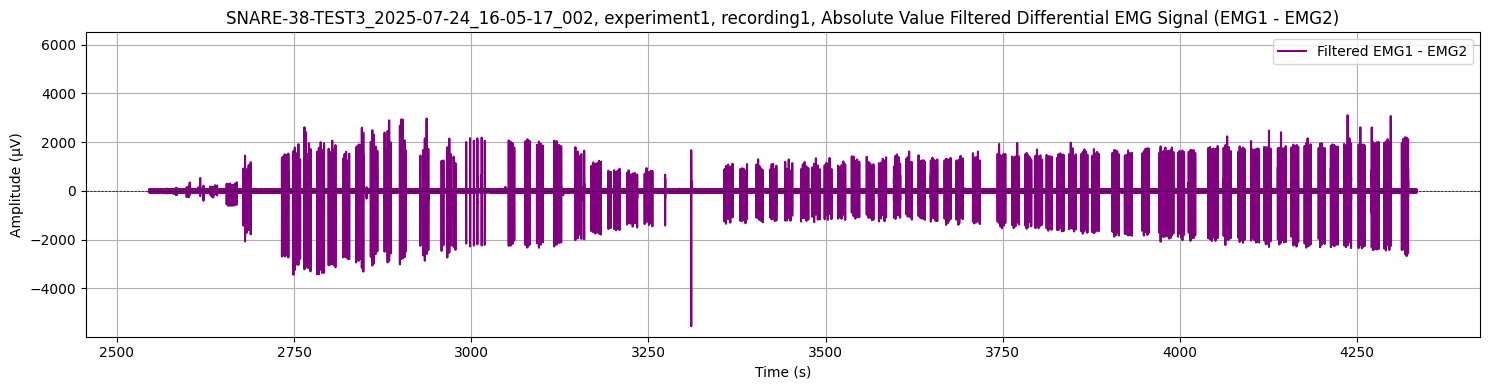

In [ ]:
x = 0
exp = "experiment1"
y = f"recording{x + 1}"
v = f"Record Node 106" if w == 0 else f"Record Node 111"

try:
    recording = session.recordnodes[w].recordings[x]
except IndexError:
    print(f"No recording {x+1} found in {exp}")
    

print(f"\n{exp.upper()}, Recording {x+1}")
print(recording)

if not any(sync.get("main", False) for sync in recording.sync_lines):
    recording.add_sync_line(1, 100, 'Rhythm Data', main=True)

recording.compute_global_timestamps()

metadata = recording.continuous[0].metadata
channel_names = metadata['channel_names']
print("Channels:", channel_names, '\n')

timestamps = recording.continuous[0].global_timestamps
data = recording.continuous[0].get_samples(0, len(timestamps))
sample_rate = metadata['sample_rate']

emg1_raw = data[:, 0]
emg2_raw = data[:, 1]
adc1 = np.abs(data[:, 2])
differential_emg = full_filter(emg2_raw - emg1_raw, sample_rate)

events = recording.events
sync_events = events[(events.line == 1) & (events.processor_id == 100) &
                        (events.stream_name == 'Rhythm Data') & (events.state == 1)]
sync_timestamps = sync_events['timestamp'].to_numpy()

messagecenter_dir = os.path.join(directory, v, exp, y, "events", "MessageCenter")
if not os.path.exists(messagecenter_dir):
    print(f"MessageCenter directory not found for {exp}/{y}")
   

texts = np.load(os.path.join(messagecenter_dir, "text.npy"), allow_pickle=True)
timestamps_msg = np.load(os.path.join(messagecenter_dir, "timestamps.npy"))
decoded_texts = [t.decode('utf-8') if isinstance(t, bytes) else str(t) for t in texts]
message_entries = list(zip(timestamps_msg, decoded_texts))
print(f"Loaded {len(decoded_texts)} MessageCenter entries")

for text, time in zip(decoded_texts, timestamps_msg):
    print(f"[Time: {time:.6f} s] Message: {text}")

plt.figure(figsize=(15, 4))
plt.plot(timestamps, differential_emg, label="Filtered EMG1 - EMG2", color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"{directory}, {exp}, {y}, Absolute Value Filtered Differential EMG Signal (EMG1 - EMG2)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (μV)")
plt.grid(True)
plt.legend()
plt.ylim(top=6500)
plt.tight_layout()
plt.show()

In [3]:
# ==== Peri-Stimulus Analysis w/ Calculated Stim Start ====
pre_event_time = 5   # ms before stim start
post_event_time = 20 # ms after stim start
stim_threshold = 0.1 # ADC1 threshold
offstim_threshold = 3

peri_stim_segments_emg = []
peri_stim_segments_adc1 = []
segment_stim_start_times = []
segment_stim_end_times = []
segment_stim_center_times = []


In [ ]:

for stamp in sync_timestamps:
    # Locate true stim start
    idx_start = np.searchsorted(timestamps, stamp)
    idx_end   = np.searchsorted(timestamps, stamp + 0.010)
    idx_center = (idx_start + idx_end)/2

    if idx_start < 0 or idx_end > len(timestamps):
        continue

    adc1_seg = adc1[idx_start:idx_end]
    time_seg = timestamps[idx_start:idx_end]

    above_idxs = np.where(adc1_seg > stim_threshold)[0]
    
    if len(above_idxs) == 0:
        continue
    stim_start_idx = idx_start + above_idxs[0]
    stim_start_time = timestamps[stim_start_idx]
    

    idx_pre  = int(stim_start_idx - (pre_event_time/1000)*sample_rate)
    idx_post = int(stim_start_idx + (post_event_time/1000)*sample_rate)
    if idx_pre < 0 or idx_post > len(timestamps):
        continue

    time_window = timestamps[idx_pre:idx_post]
    time_zeroed = time_window - stim_start_time

    seg_emg  = differential_emg[idx_pre:idx_post]
    seg_adc1 = adc1[idx_pre:idx_post]

    # Determine stim end
    post_mask = (time_zeroed >= 0)
    adc1_post = seg_adc1[post_mask]
    time_post = time_zeroed[post_mask]
    below_idxs = np.where(adc1_post < offstim_threshold)[0]

    
    stim_end_time = (time_post[below_idxs[0]]*1000 if len(below_idxs)>0 else post_event_time)

    peri_stim_segments_emg.append(seg_emg)
    peri_stim_segments_adc1.append(seg_adc1)
    segment_stim_start_times.append(stim_start_time)
    segment_stim_end_times.append(stim_end_time)



In [6]:
print(time_window)
print(idx_center)
print(idx_start)
print(idx_end)
print(post_event_time)
print(stim_end_time)
type(stim_end_time)


[4321.8846 4321.8848 4321.885  4321.8852 4321.8854 4321.8856 4321.8858
 4321.886  4321.8862 4321.8864 4321.8866 4321.8868 4321.887  4321.8872
 4321.8874 4321.8876 4321.8878 4321.888  4321.8882 4321.8884 4321.8886
 4321.8888 4321.889  4321.8892 4321.8894 4321.8896 4321.8898 4321.89
 4321.8902 4321.8904 4321.8906 4321.8908 4321.891  4321.8912 4321.8914
 4321.8916 4321.8918 4321.892  4321.8922 4321.8924 4321.8926 4321.8928
 4321.893  4321.8932 4321.8934 4321.8936 4321.8938 4321.894  4321.8942
 4321.8944 4321.8946 4321.8948 4321.895  4321.8952 4321.8954 4321.8956
 4321.8958 4321.896  4321.8962 4321.8964 4321.8966 4321.8968 4321.897
 4321.8972 4321.8974 4321.8976 4321.8978 4321.898  4321.8982 4321.8984
 4321.8986 4321.8988 4321.899  4321.8992 4321.8994 4321.8996 4321.8998
 4321.9    4321.9002 4321.9004 4321.9006 4321.9008 4321.901  4321.9012
 4321.9014 4321.9016 4321.9018 4321.902  4321.9022 4321.9024 4321.9026
 4321.9028 4321.903  4321.9032 4321.9034 4321.9036 4321.9038 4321.904
 4321.9042

numpy.float64

In [7]:
# ==== Dynamically determine stimulation groups ====
trigger_pattern = re.compile(r"RHDCONTROL TRIGGER")
stim_pattern = re.compile(r"starting(?: at)? (\d+\.?\d*)\s*mA", re.IGNORECASE)

stim_groups = []
current_group = []
current_amp = None

for t, msg in message_entries:
    if stim_pattern.search(msg):
        if current_amp is not None and current_group:
            stim_groups.append((current_amp, current_group))
        current_amp = float(stim_pattern.search(msg).group(1))
        current_group = []
    elif trigger_pattern.search(msg):
        if current_amp is not None:
            current_group.append(t)

if current_amp is not None and current_group:
    stim_groups.append((current_amp, current_group))

In [8]:
# ==== Match each stim group to detected peri-stim segments ====
time_ms = np.linspace(-pre_event_time, post_event_time,
                    int((pre_event_time+post_event_time)/1000*sample_rate))


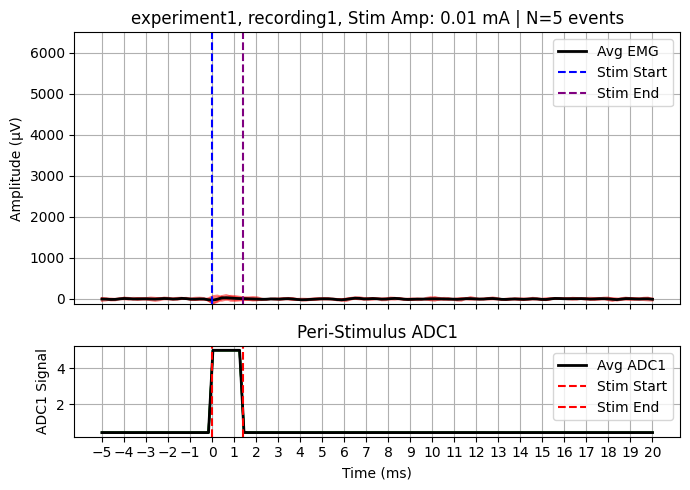

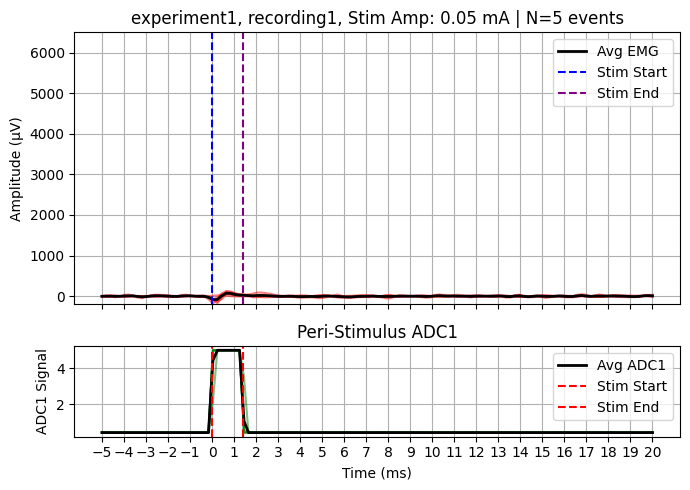

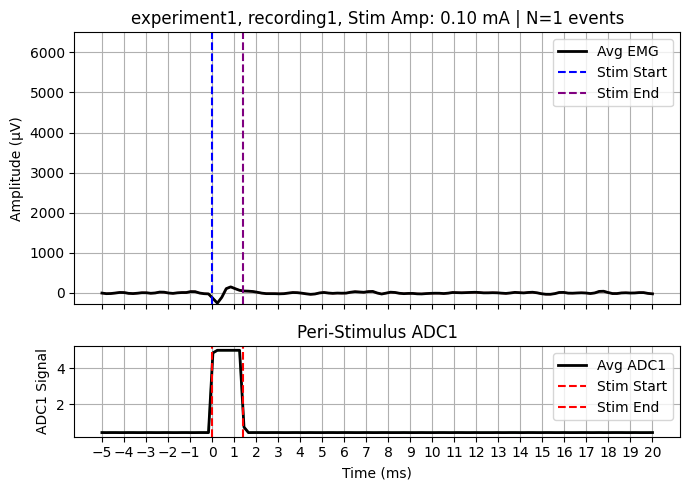

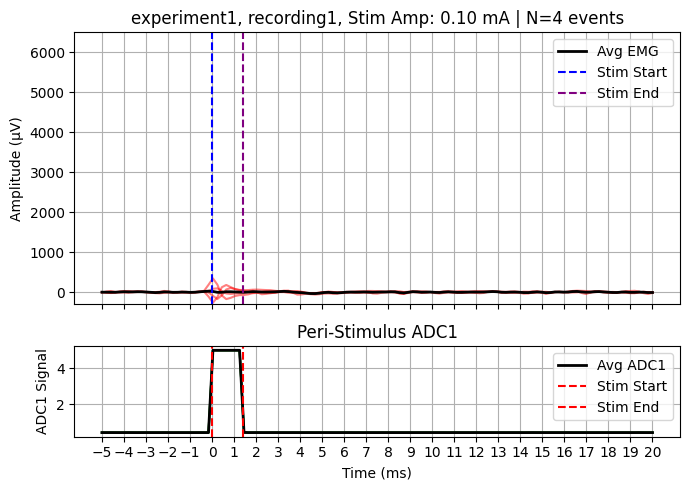

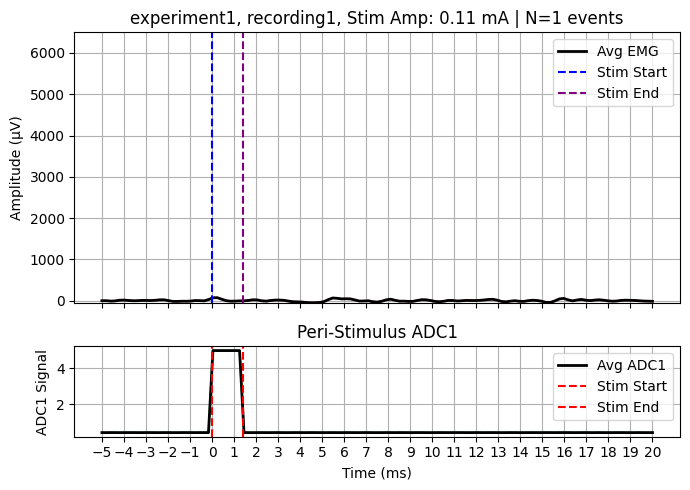

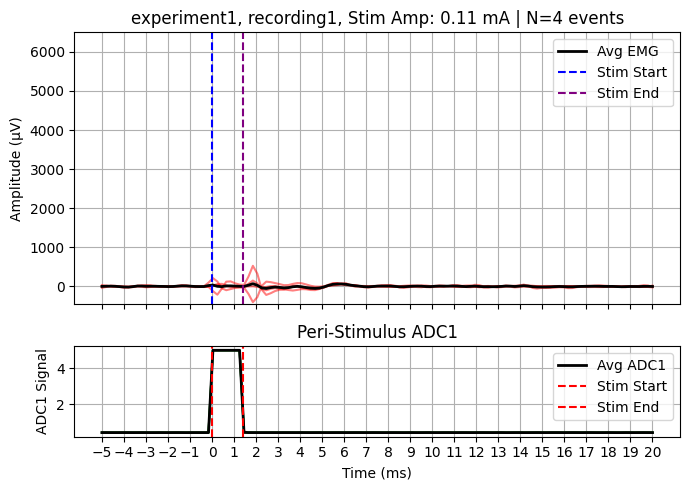

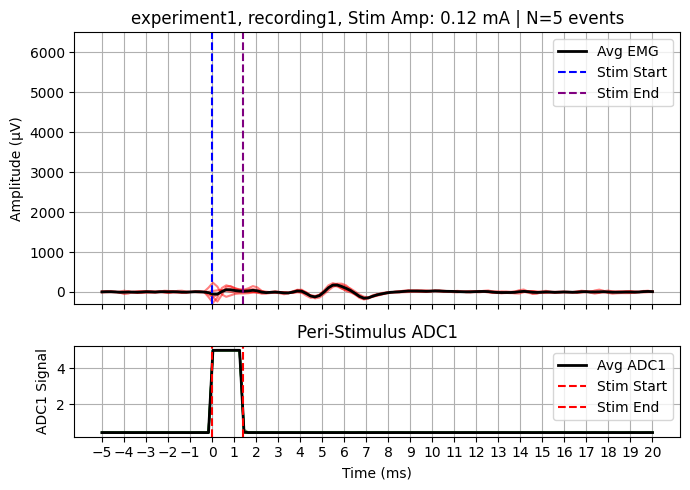

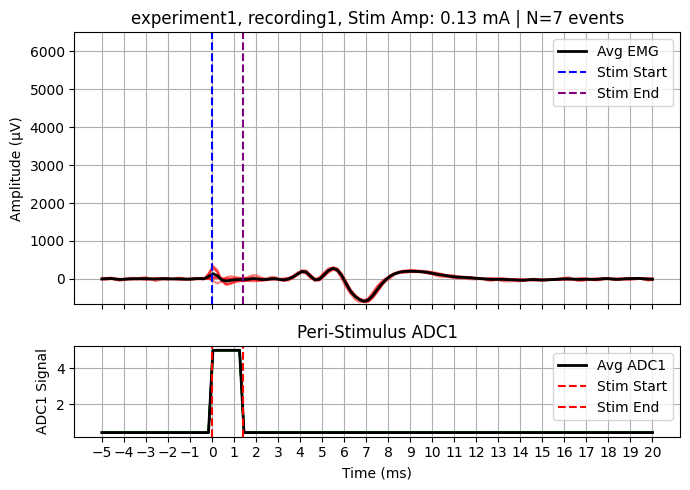

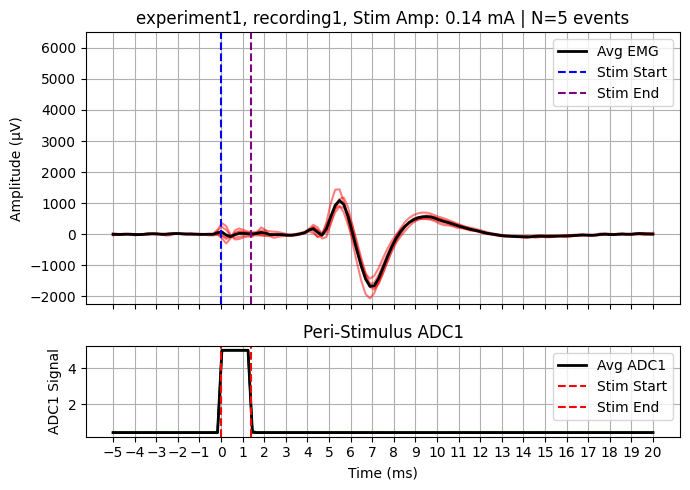

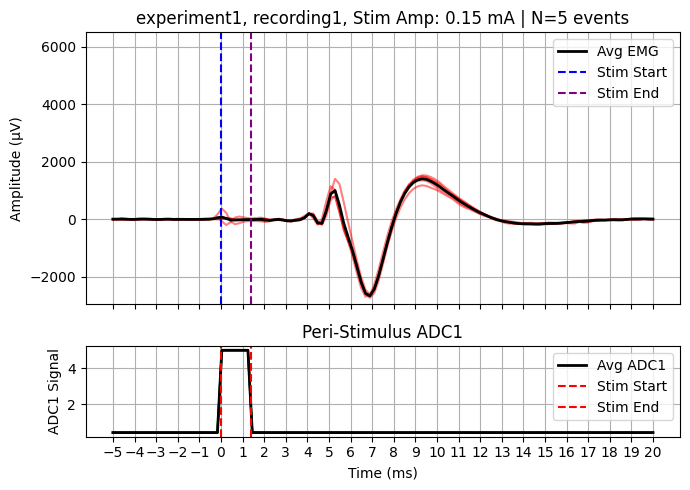

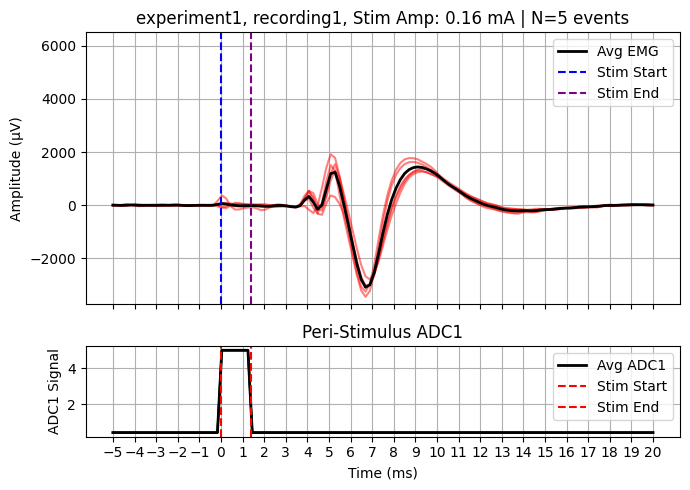

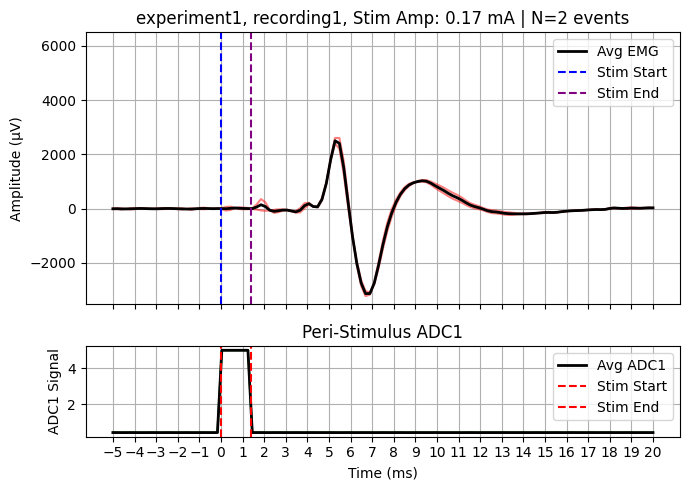

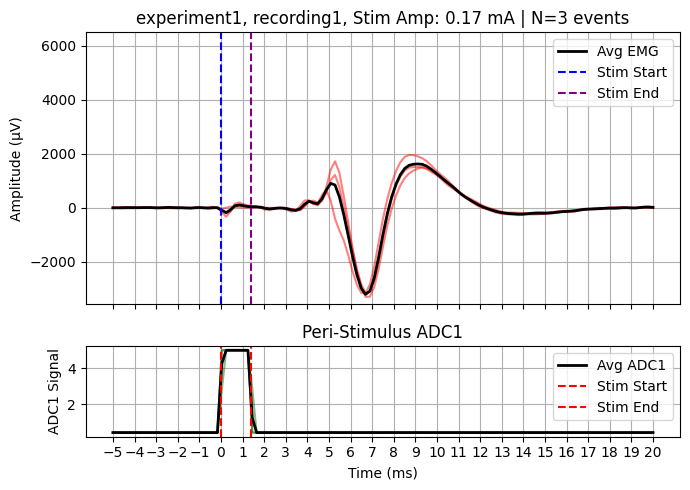

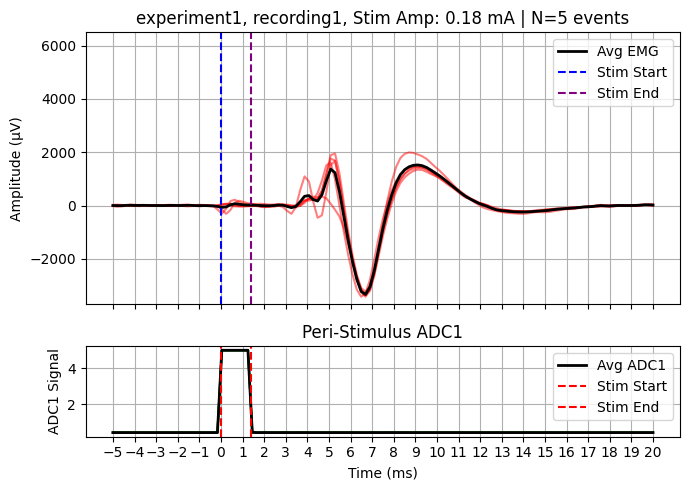

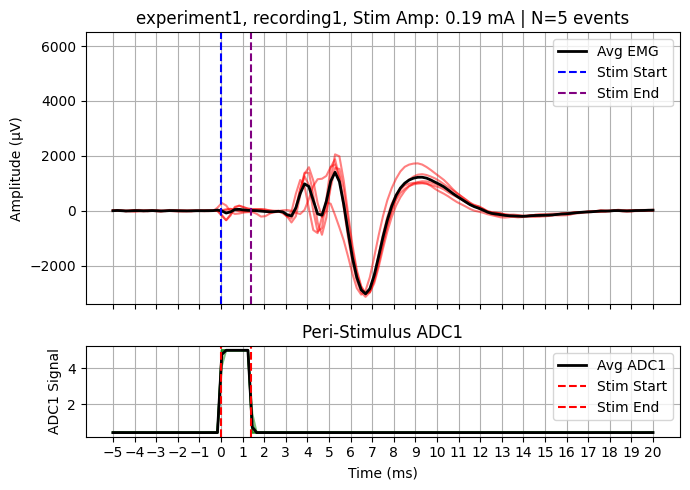

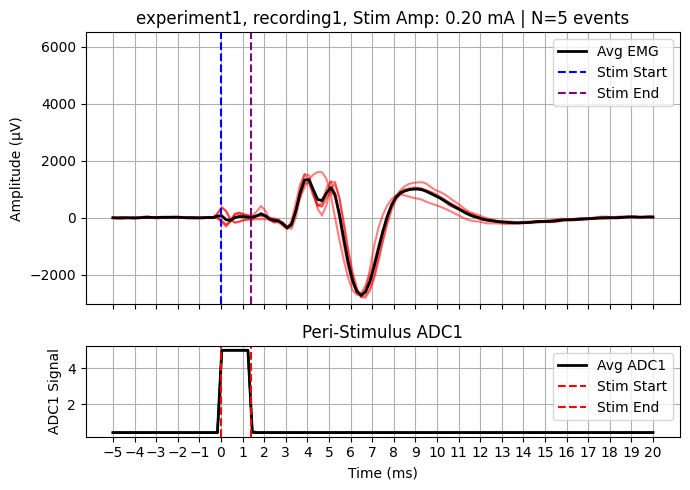

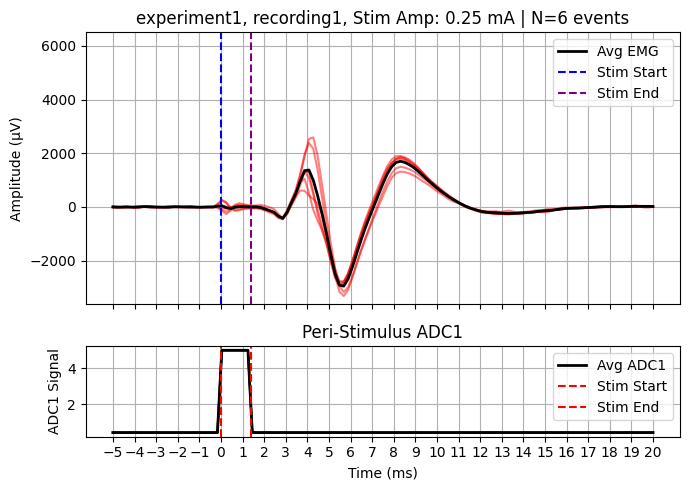

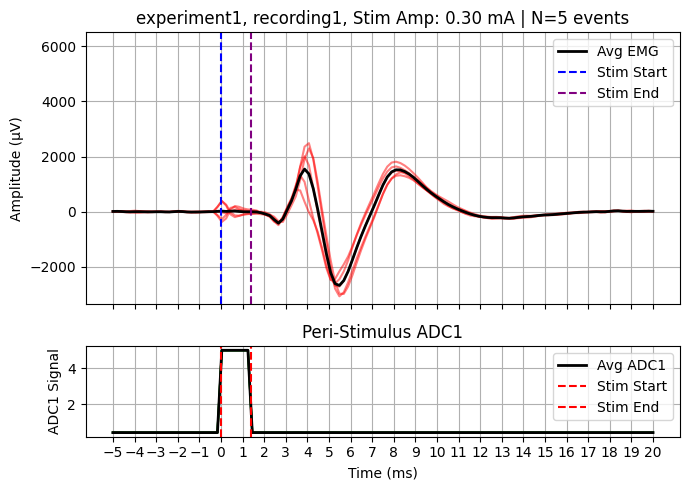

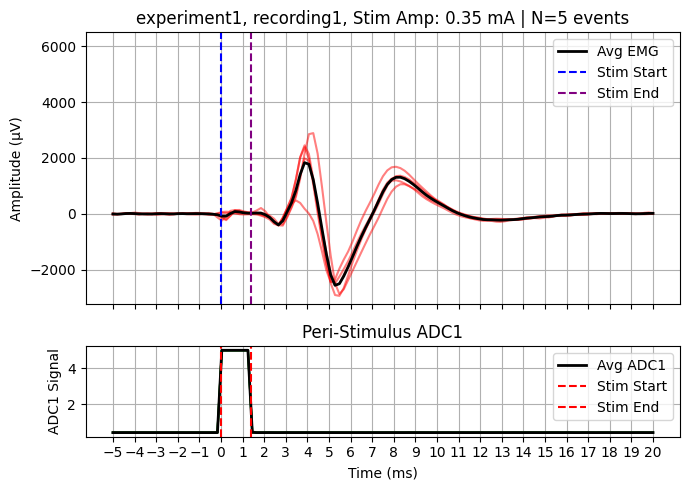

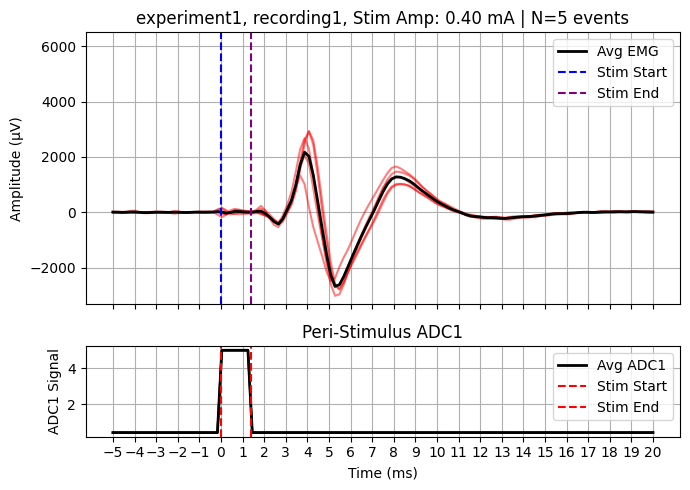

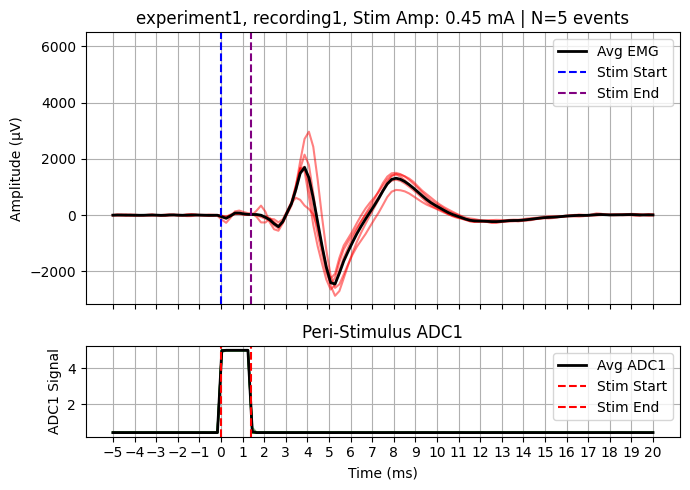

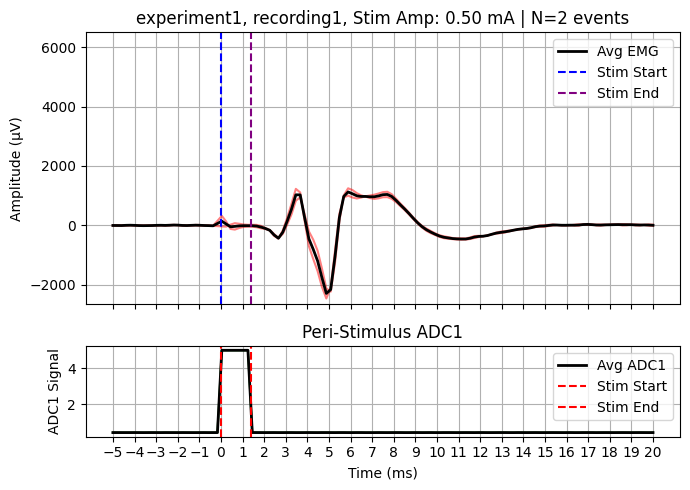

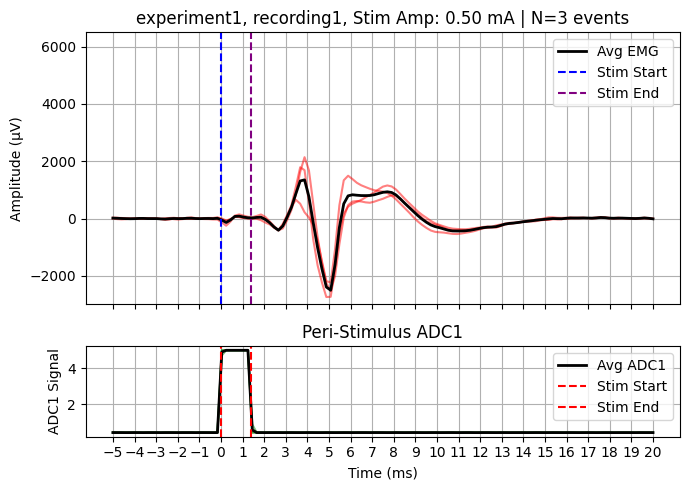

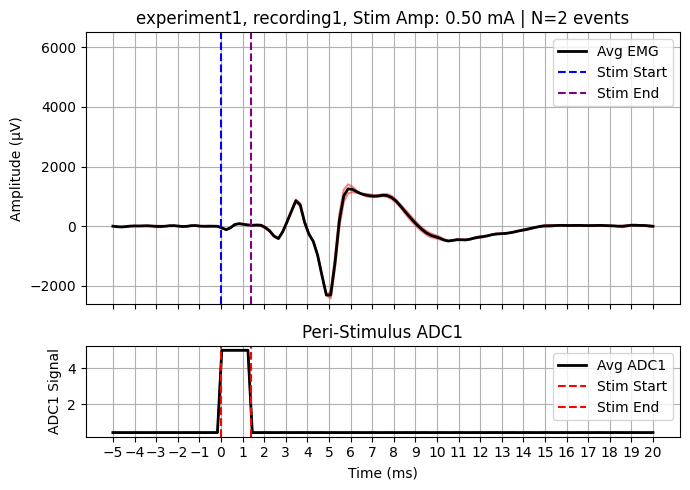

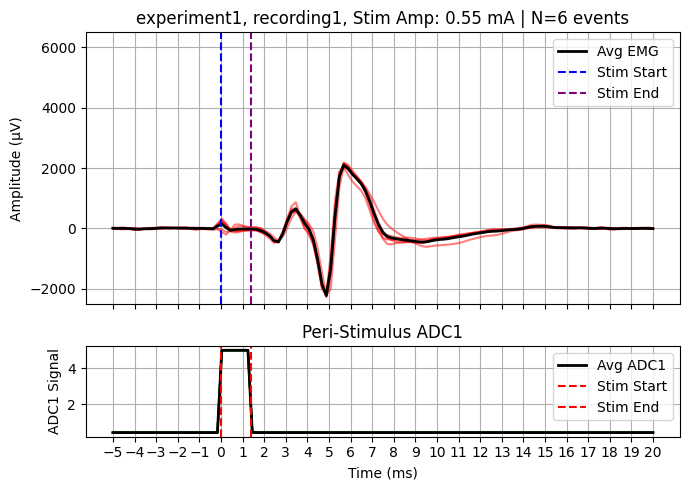

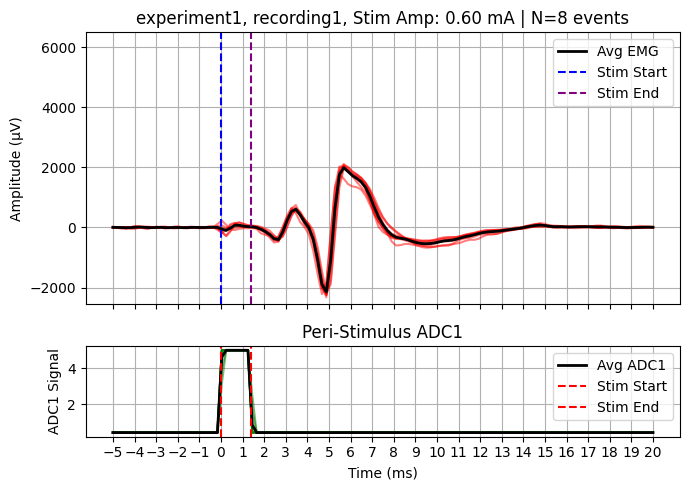

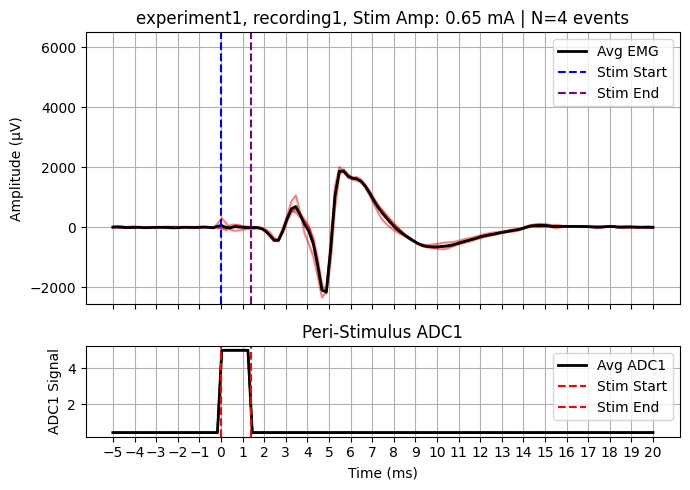

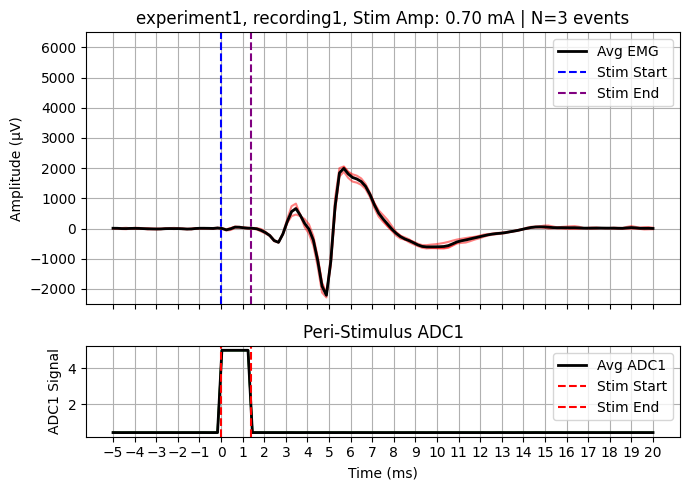

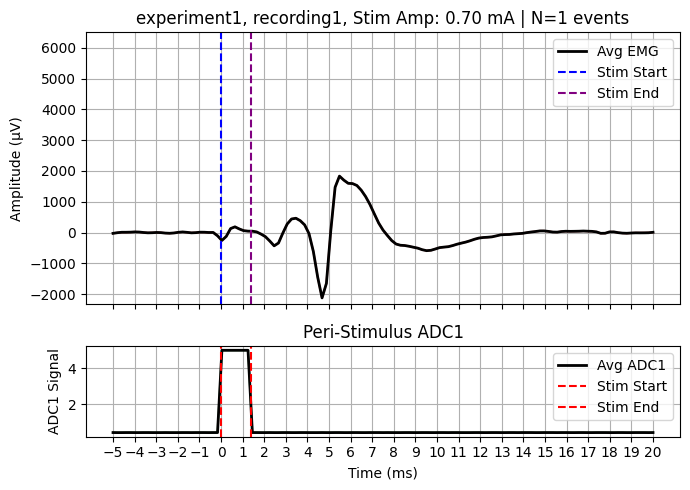

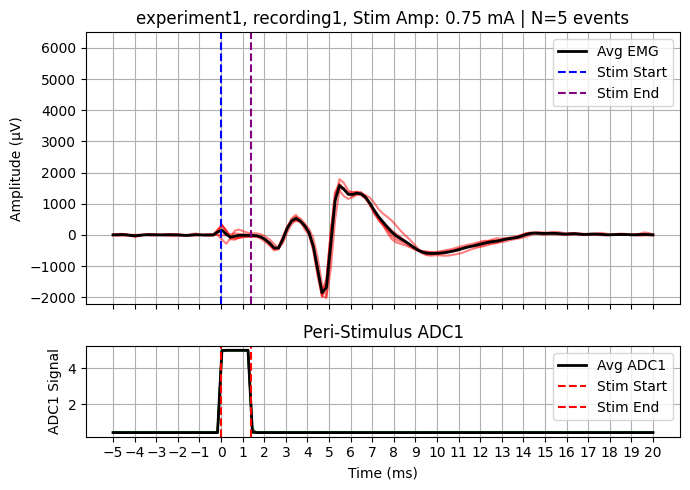

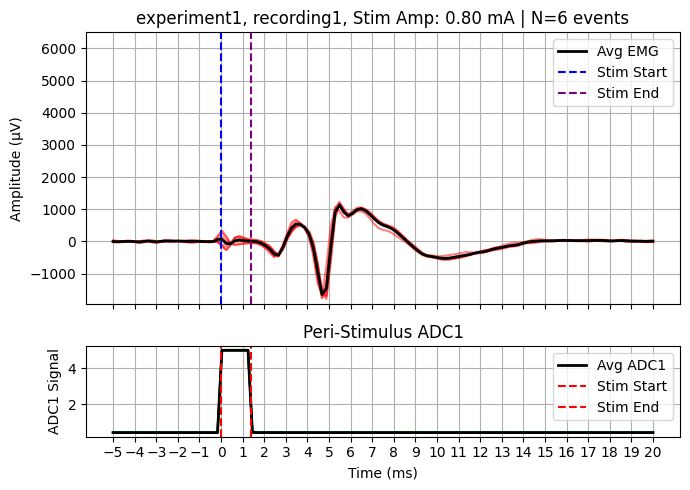

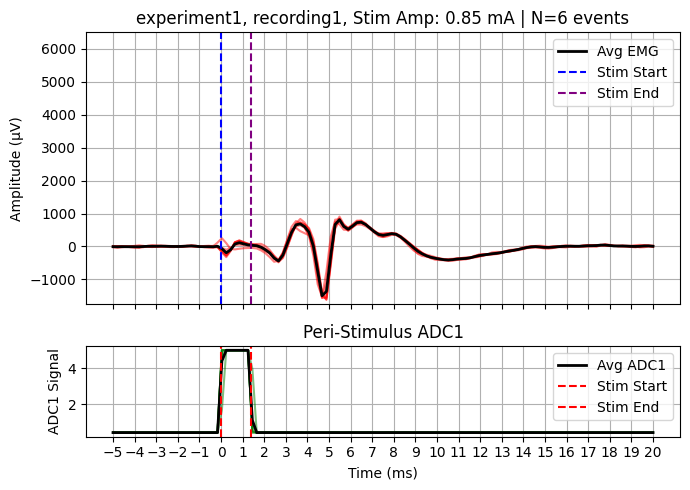

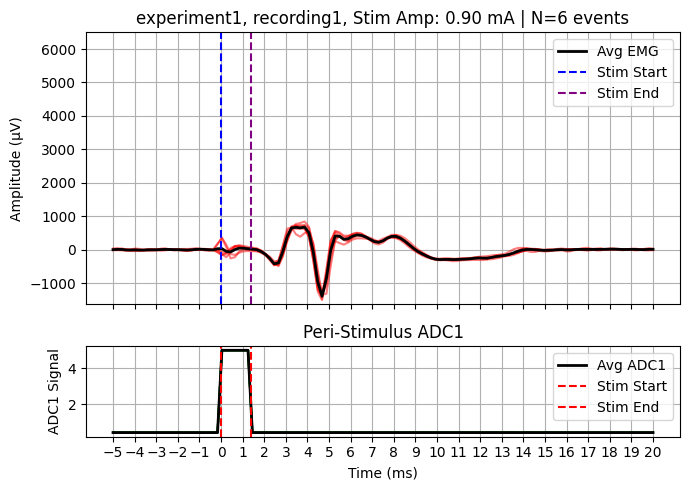

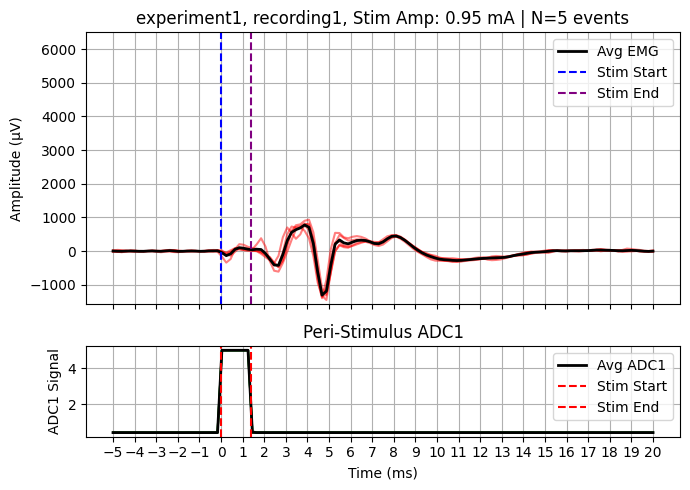

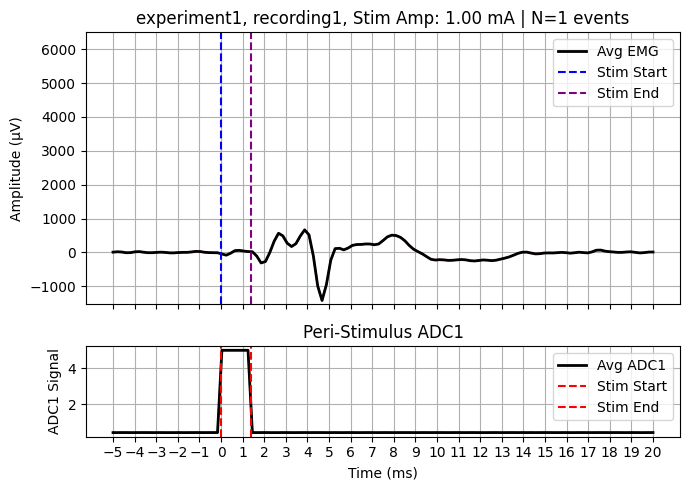

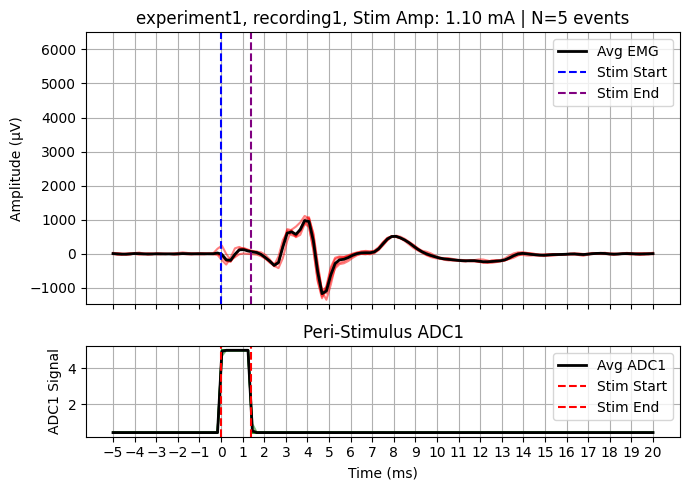

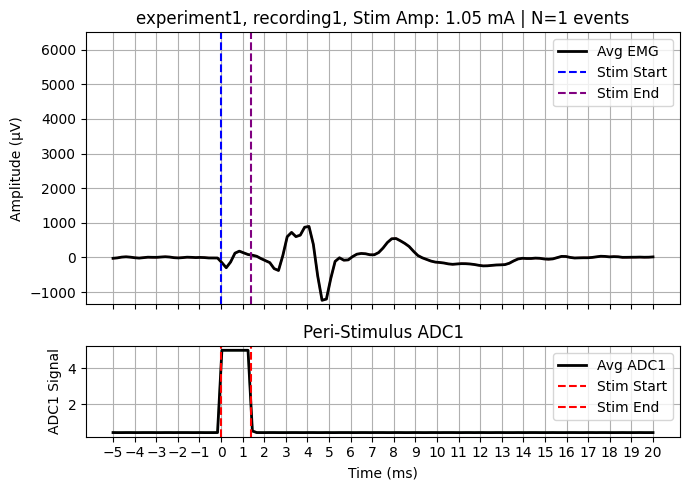

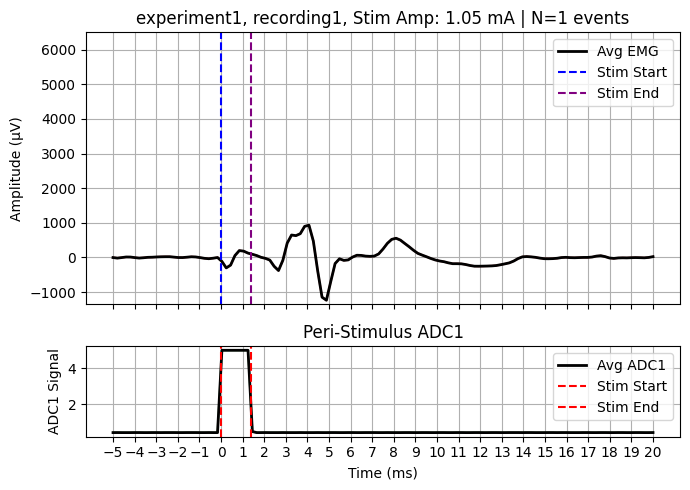

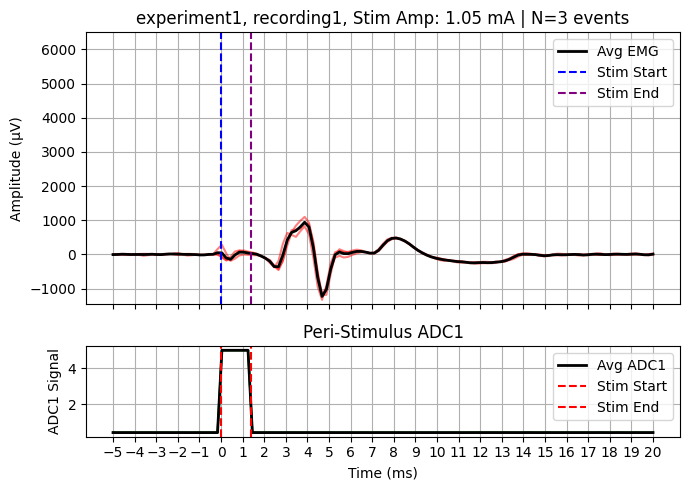

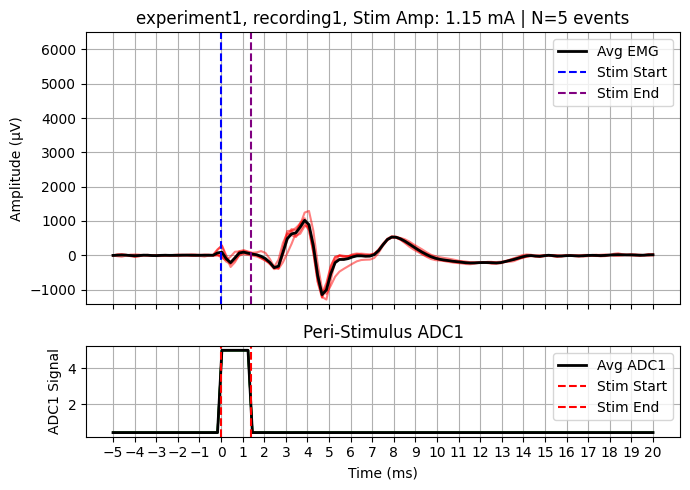

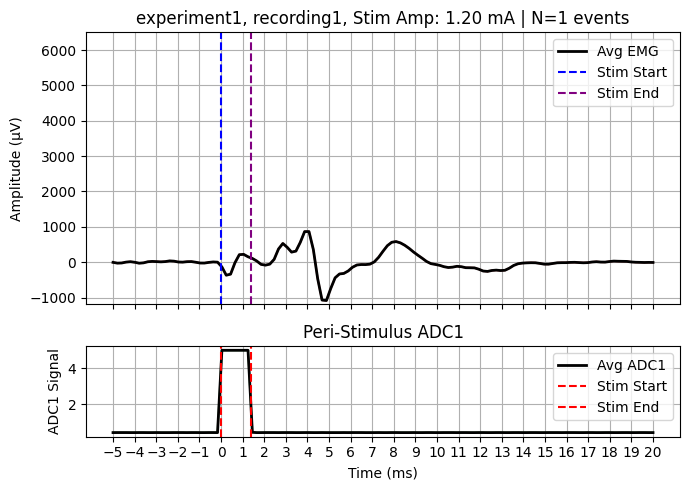

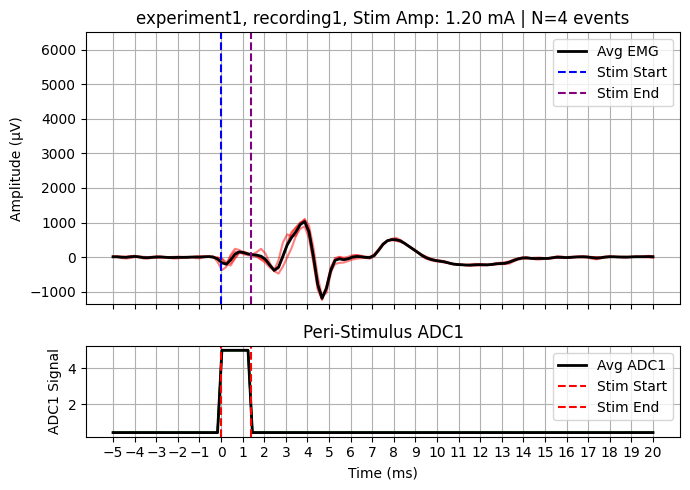

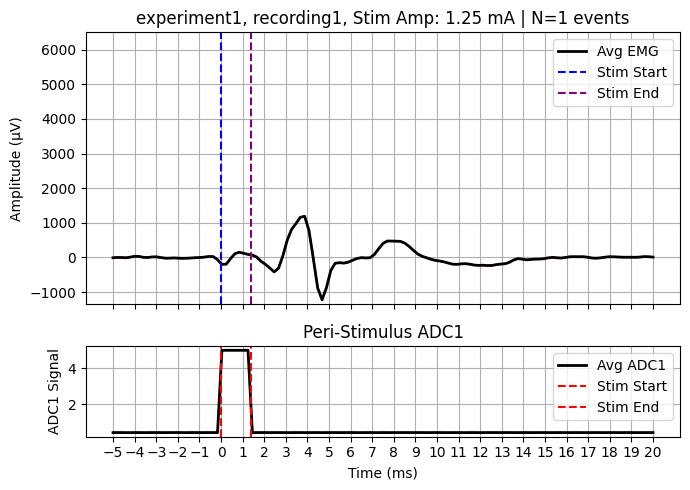

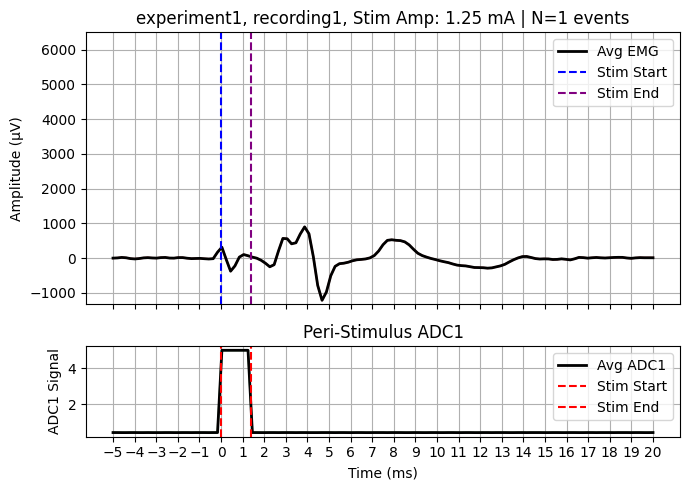

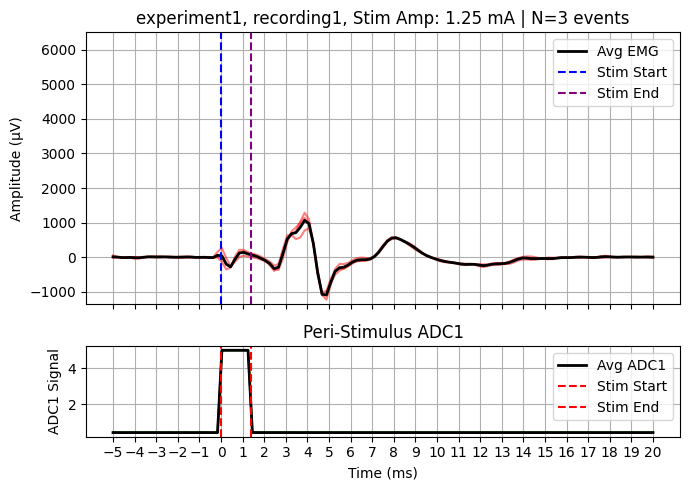

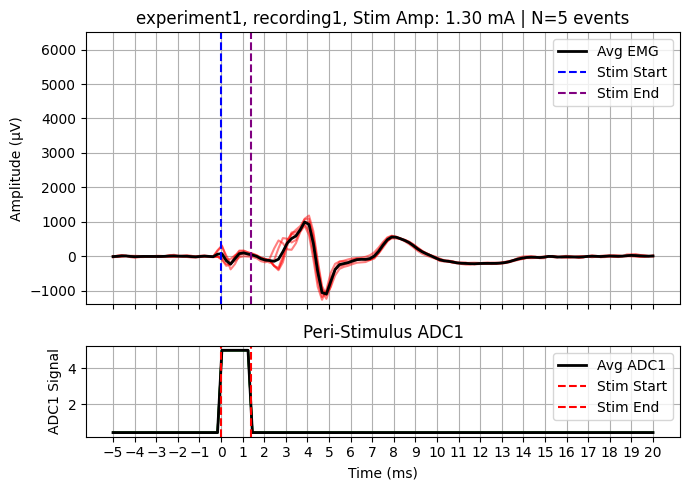

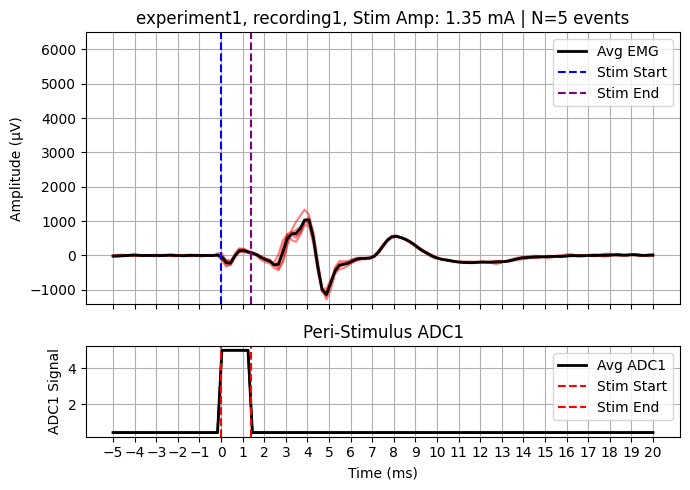

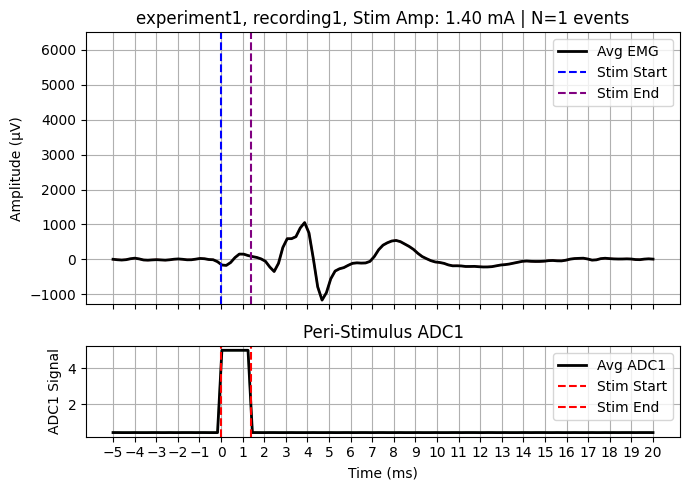

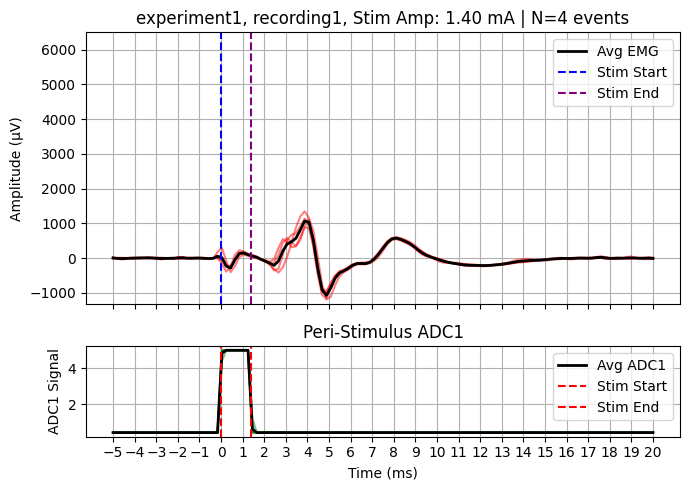

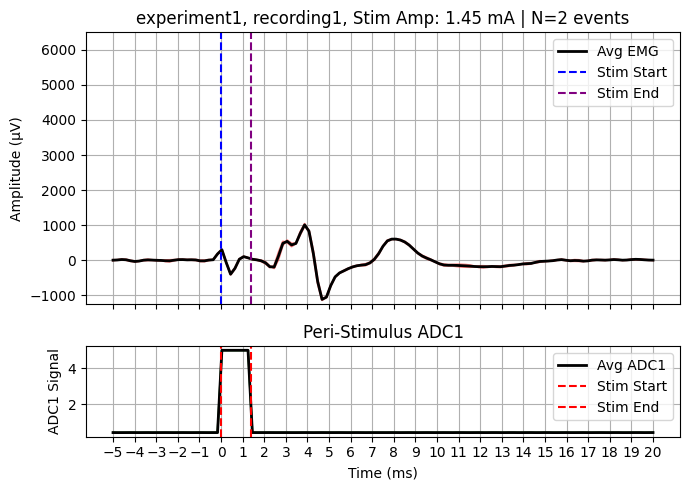

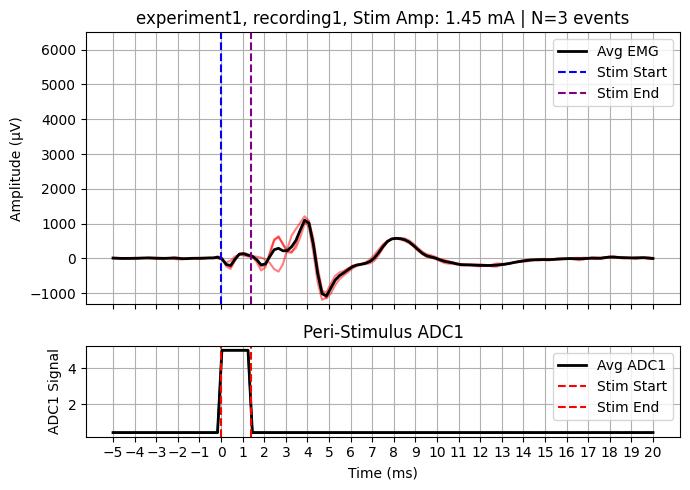

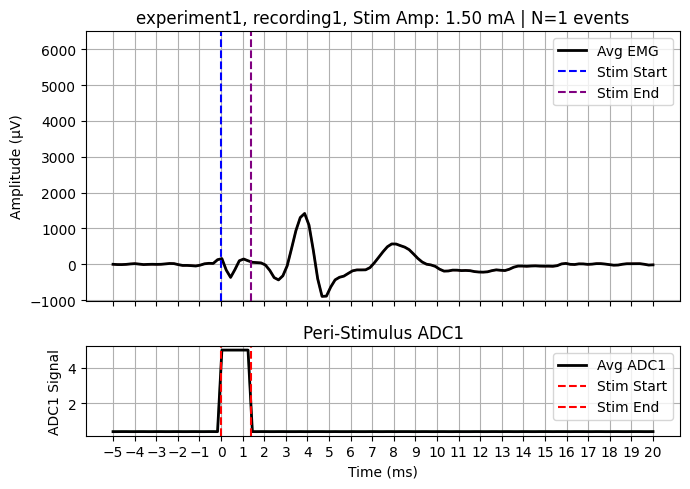

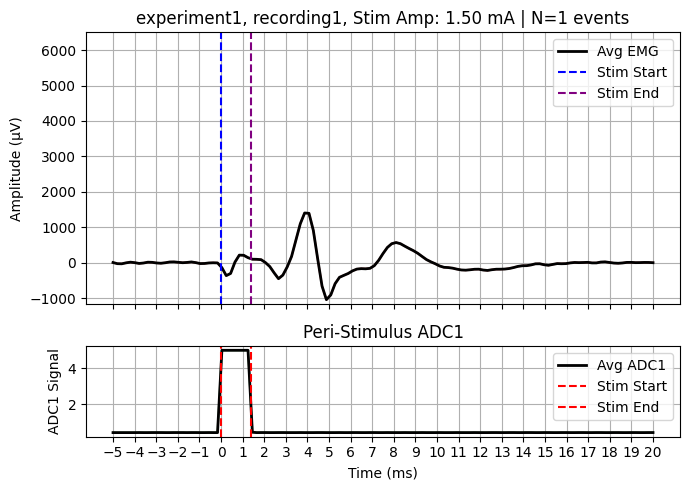

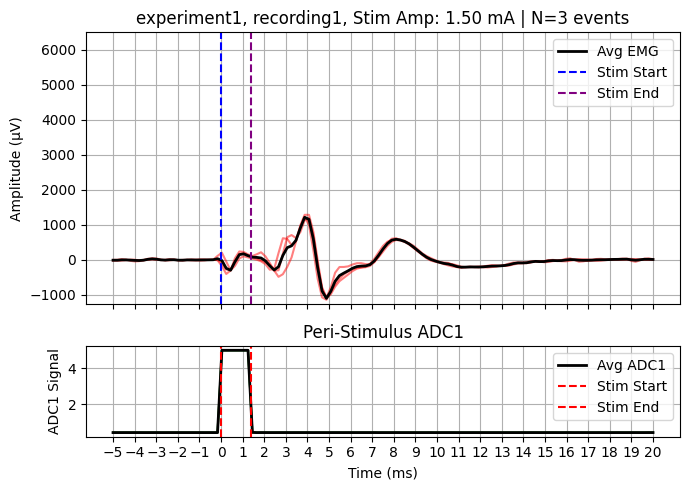

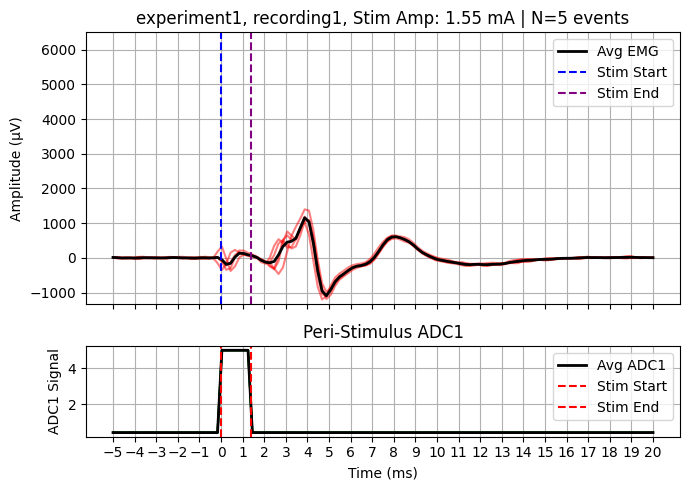

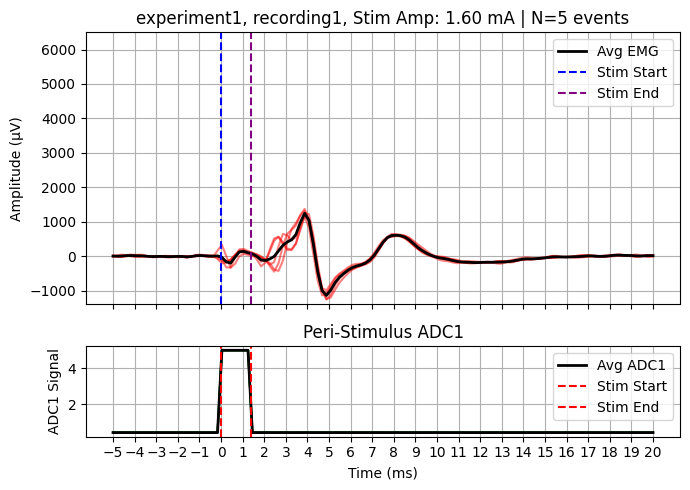

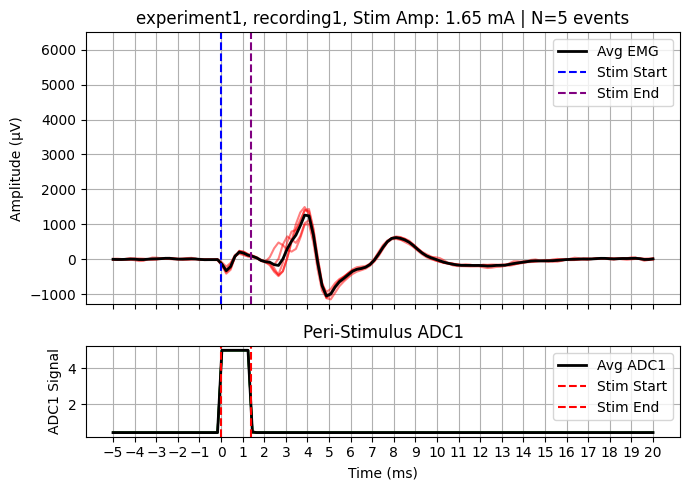

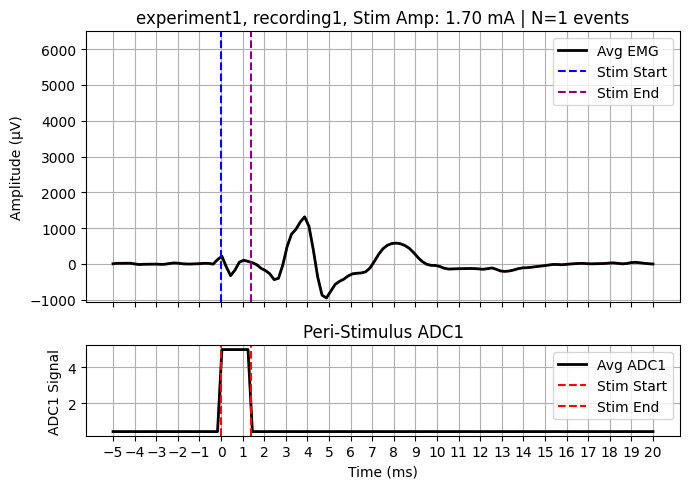

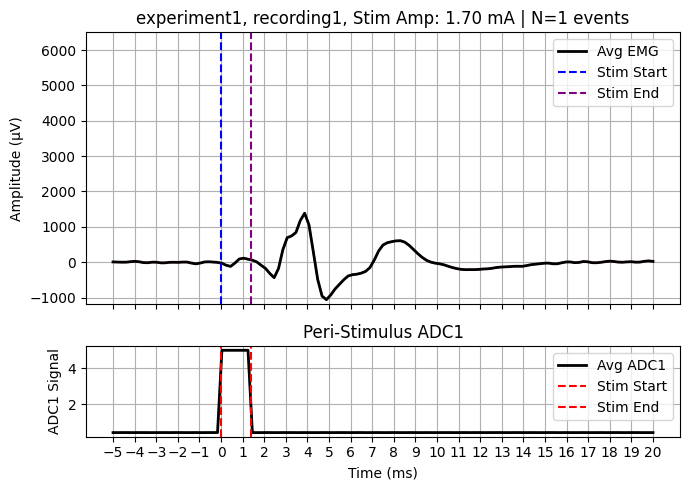

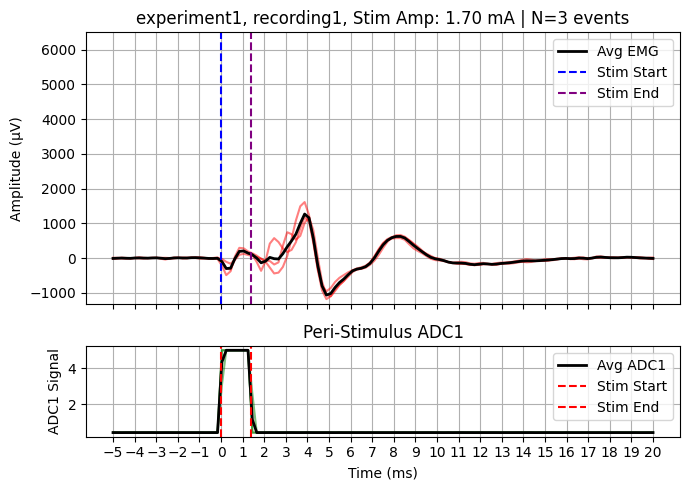

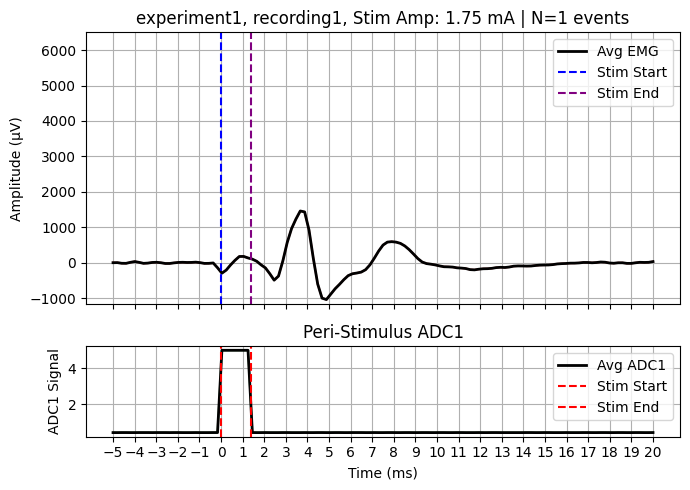

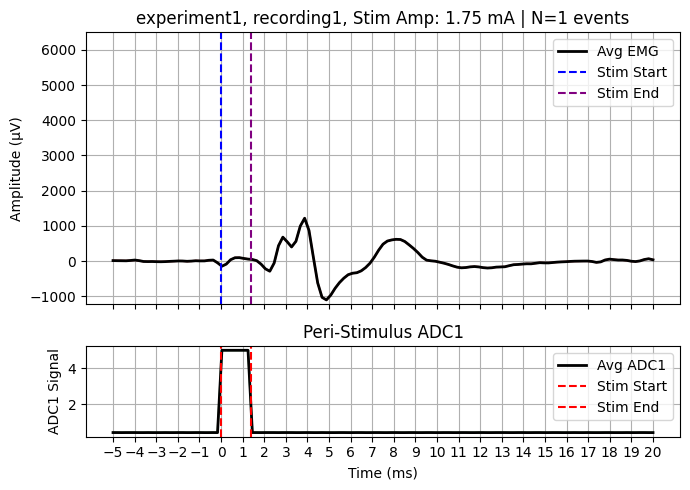

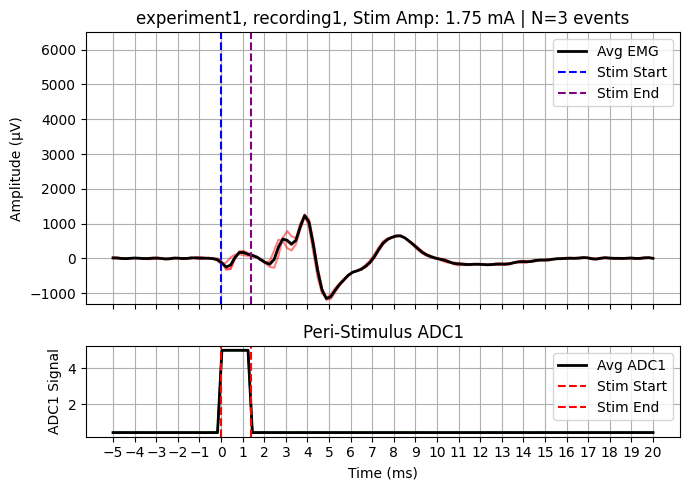

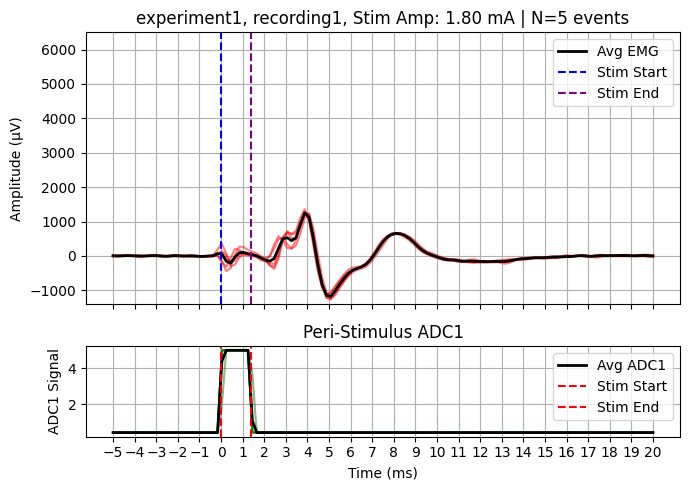

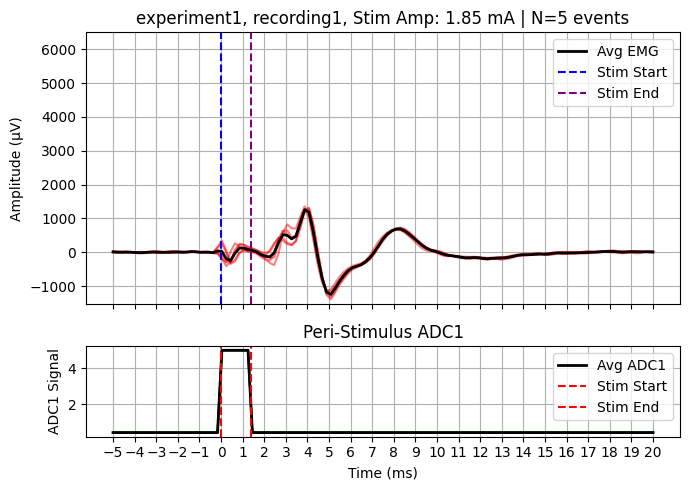

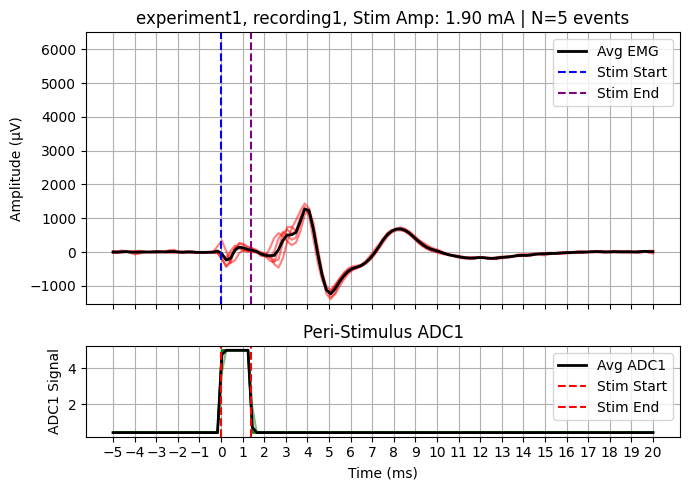

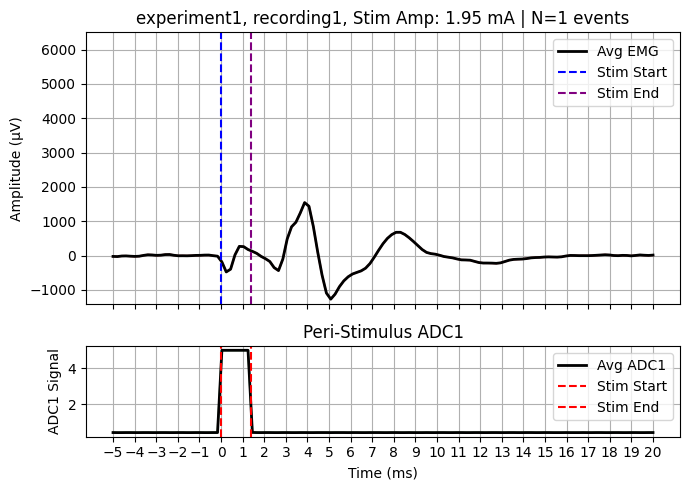

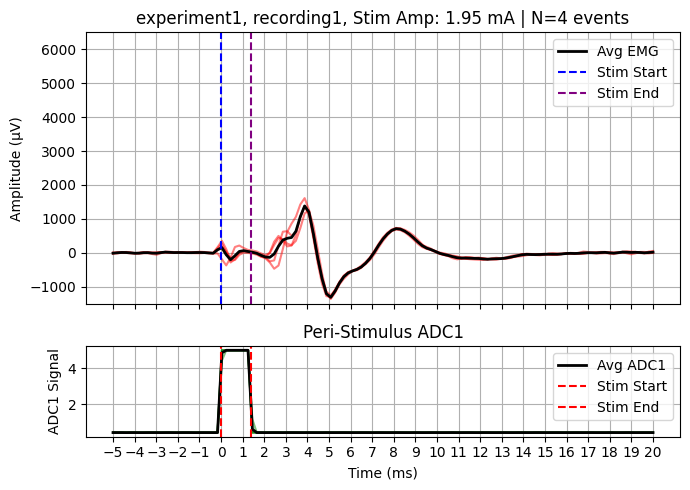

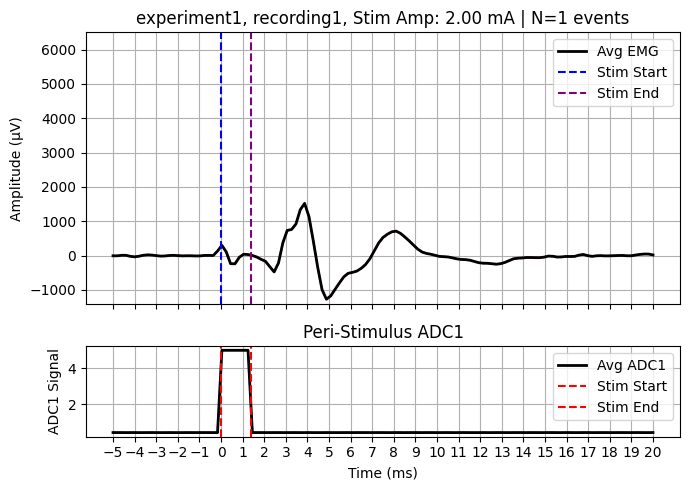

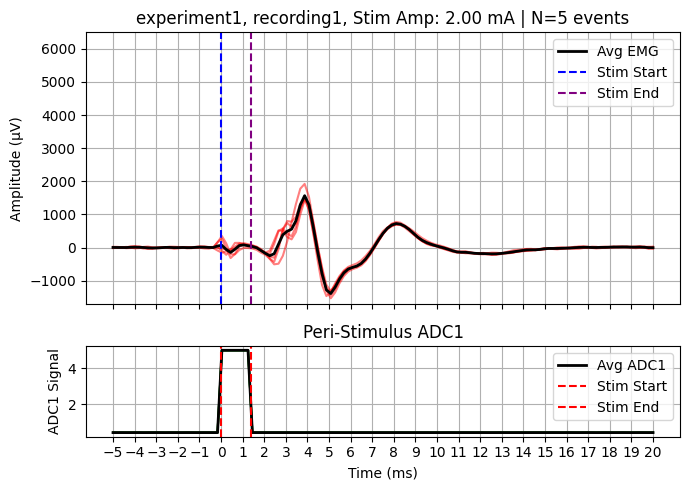

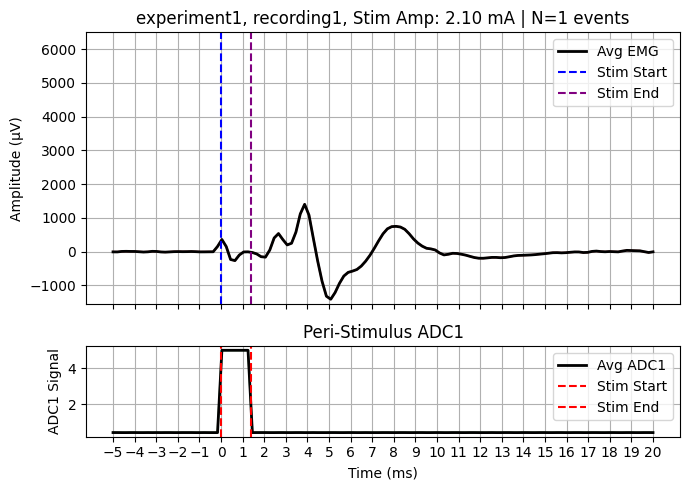

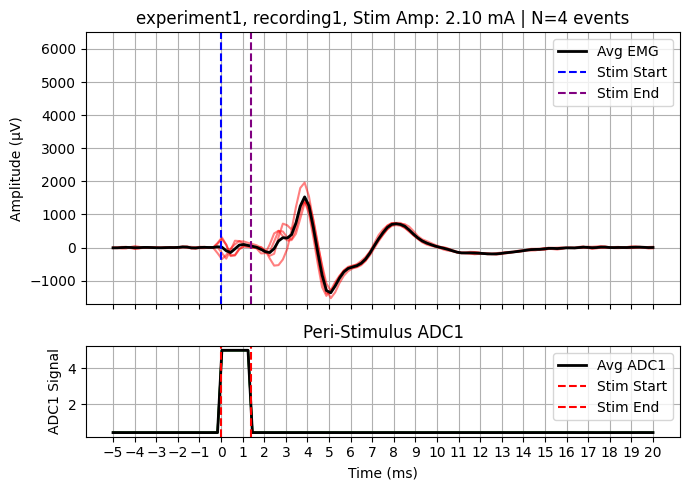

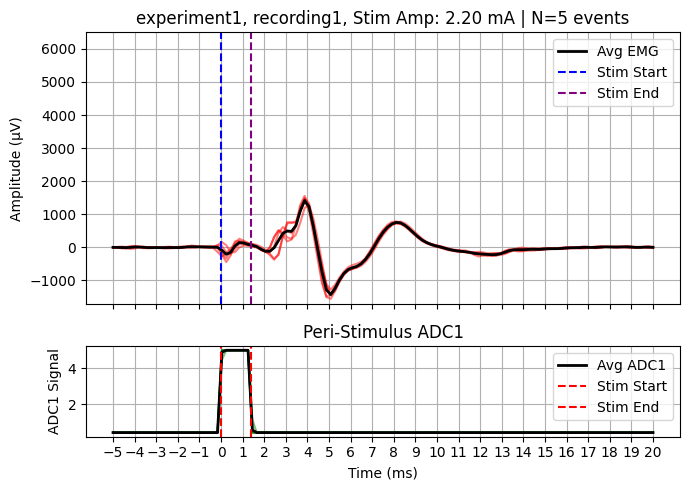

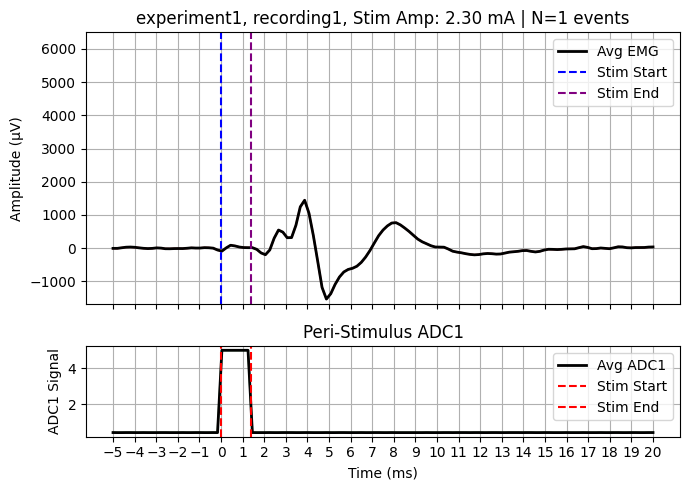

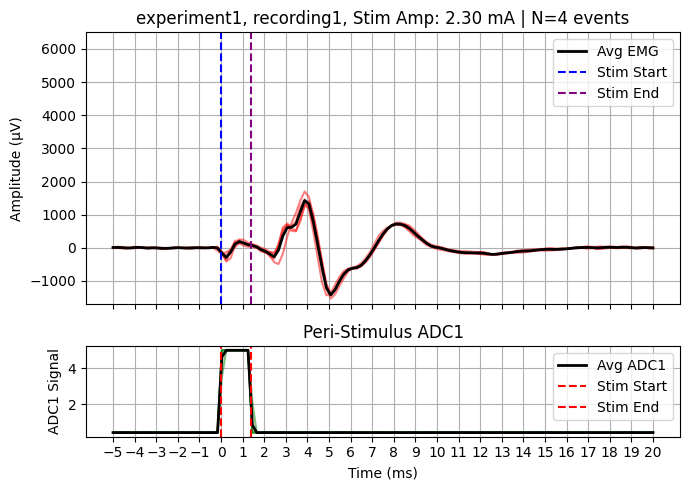

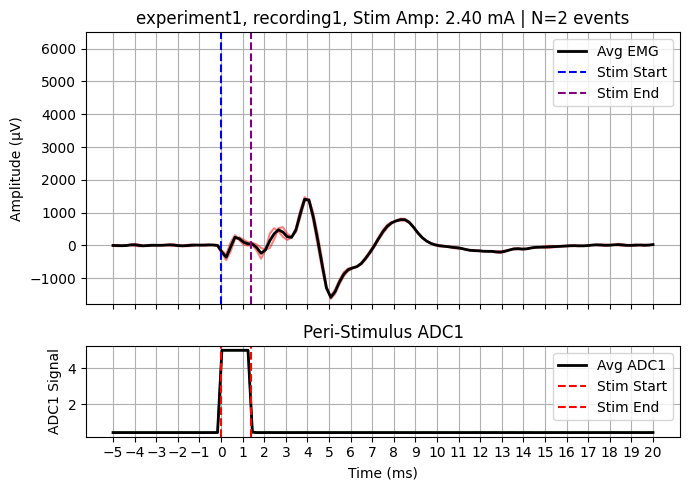

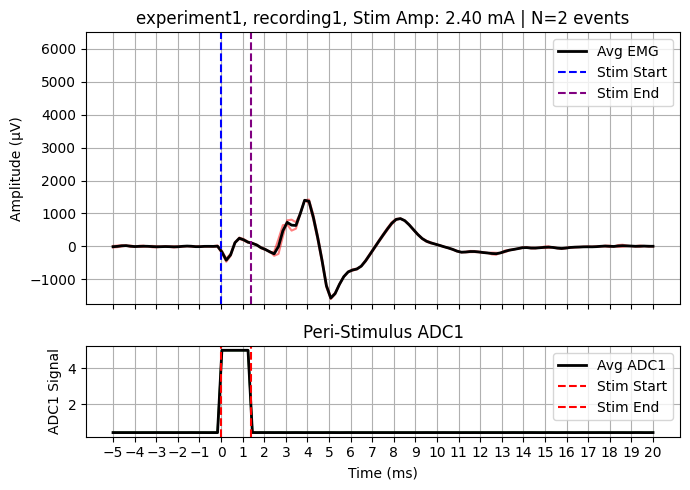

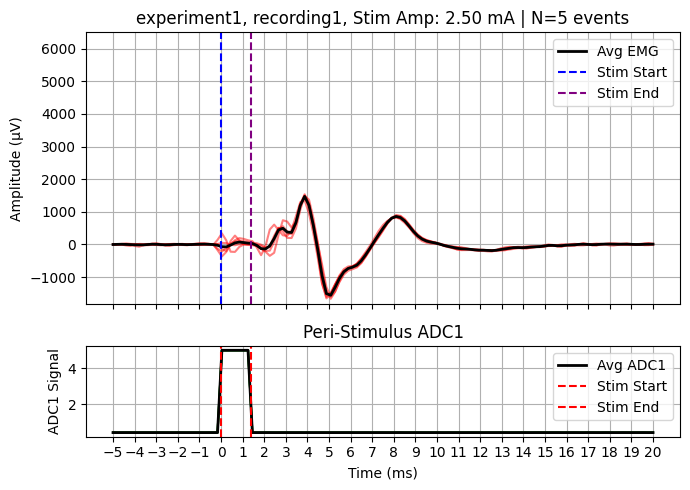

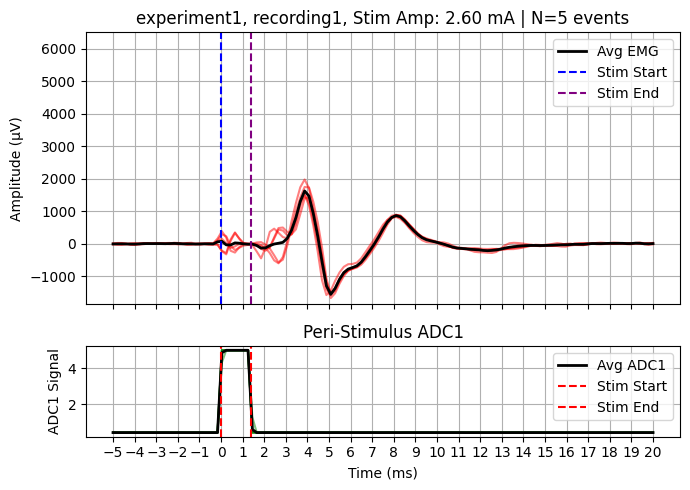

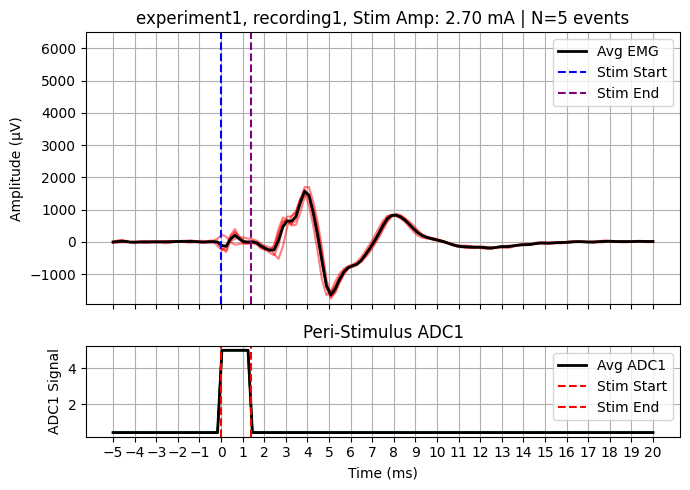

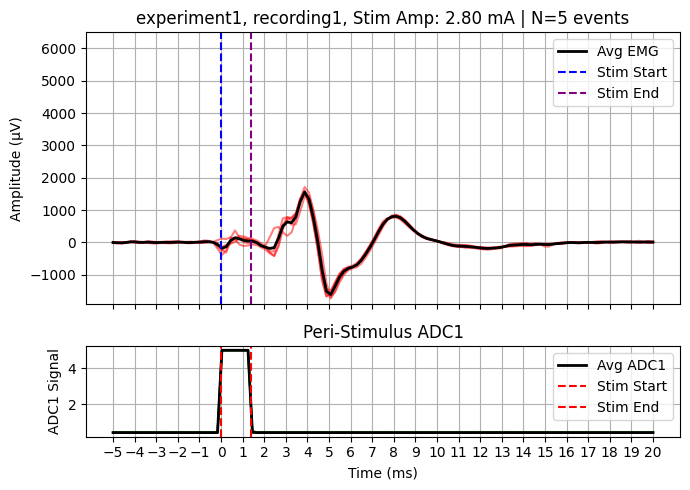

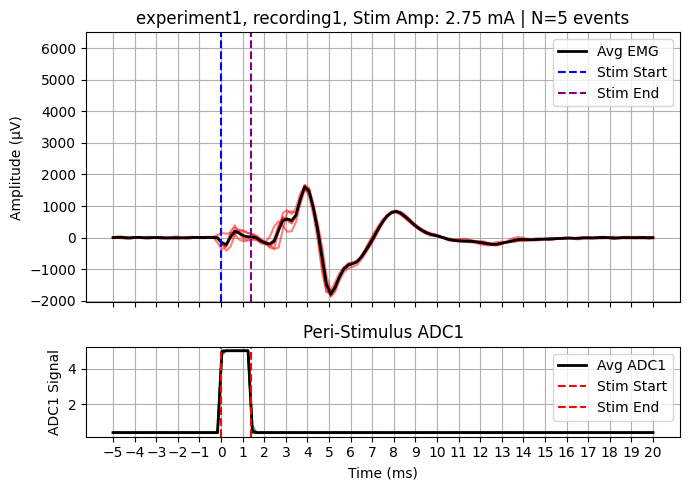

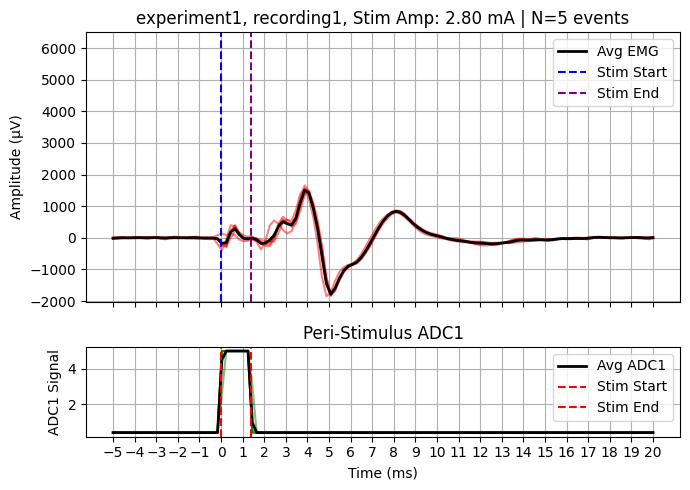

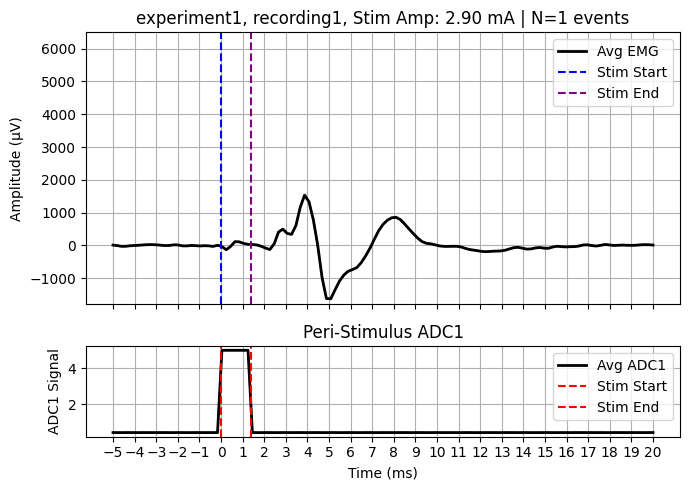

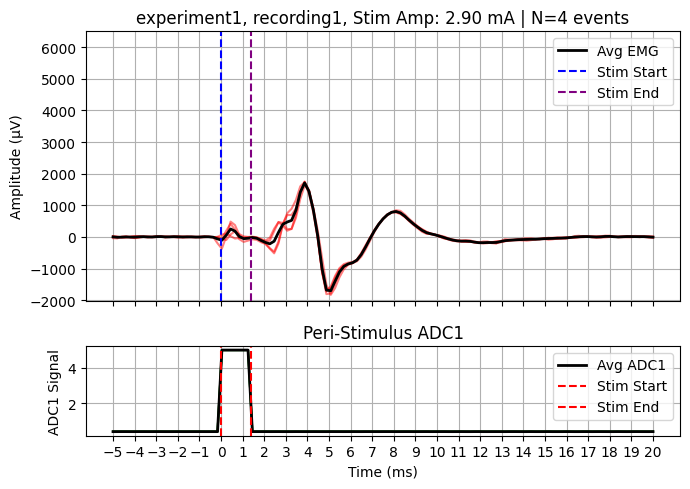

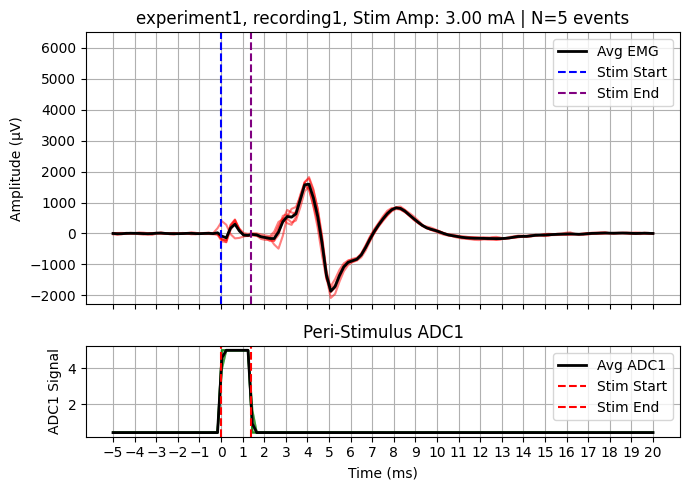

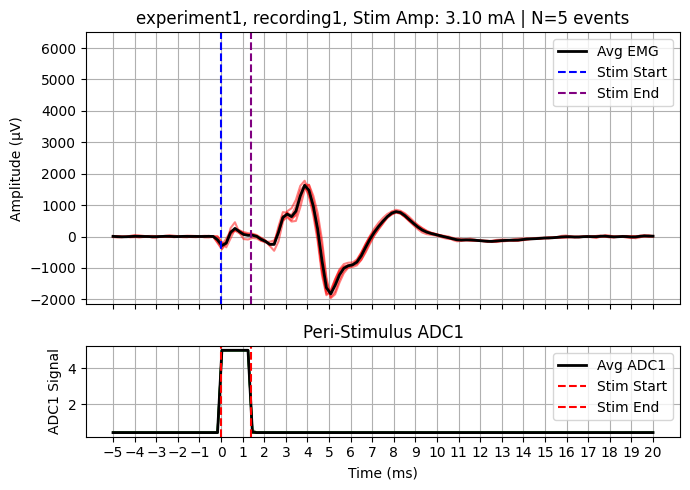

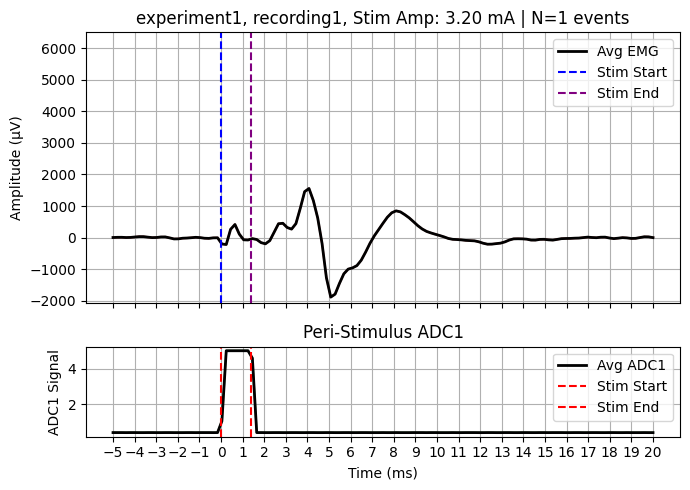

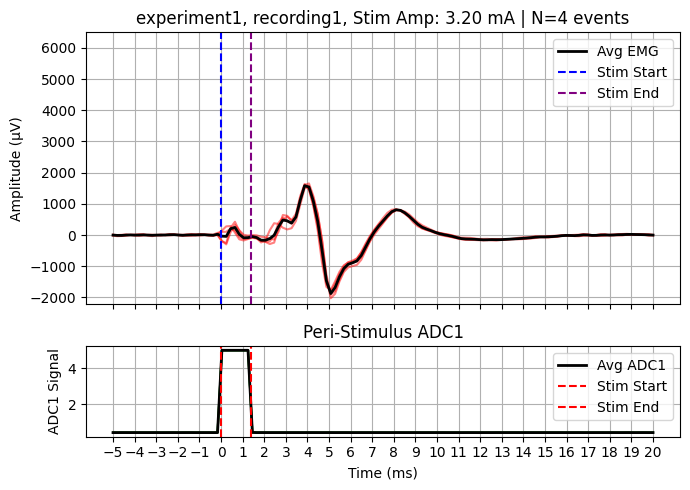

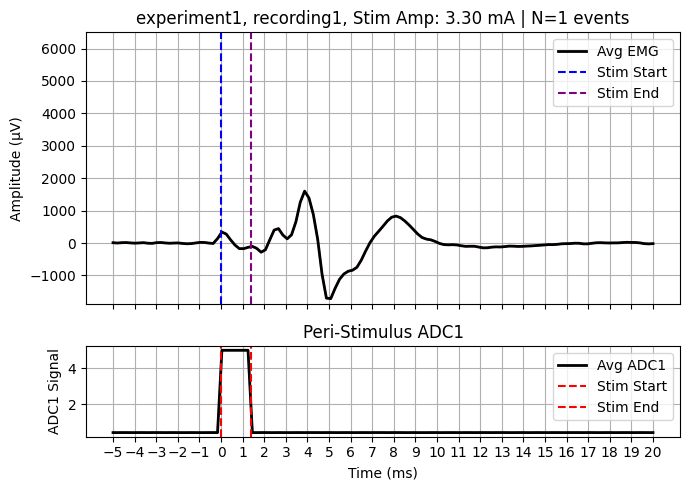

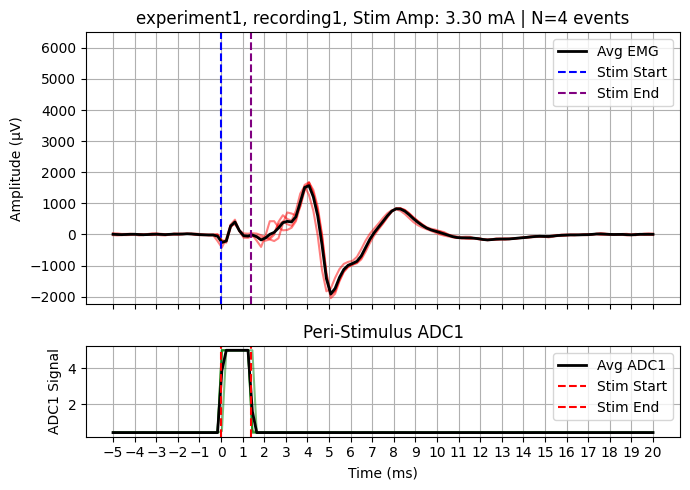

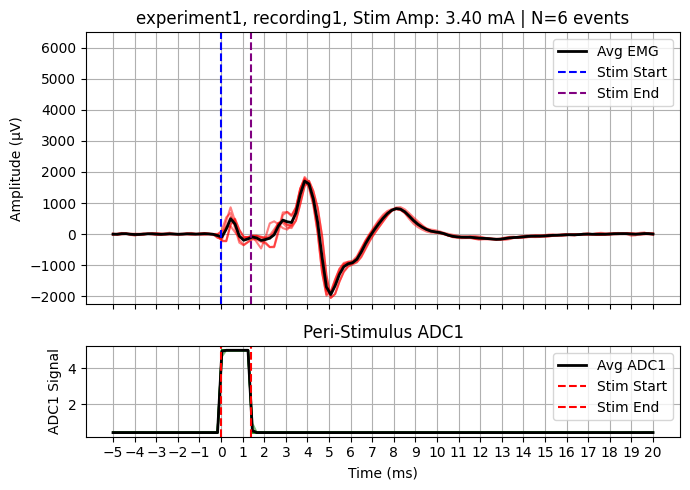

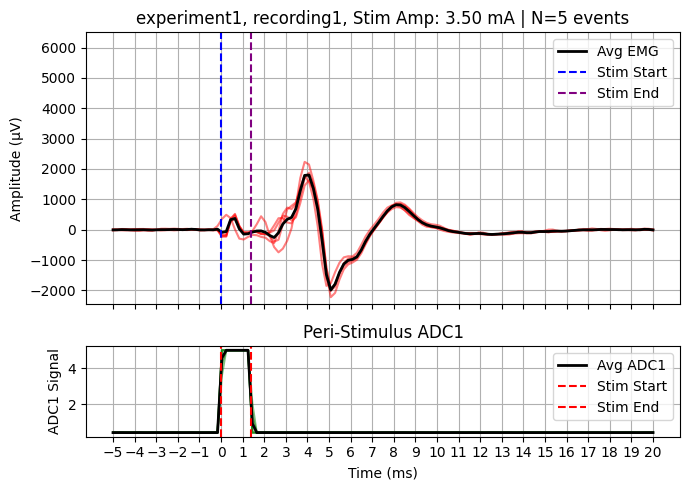

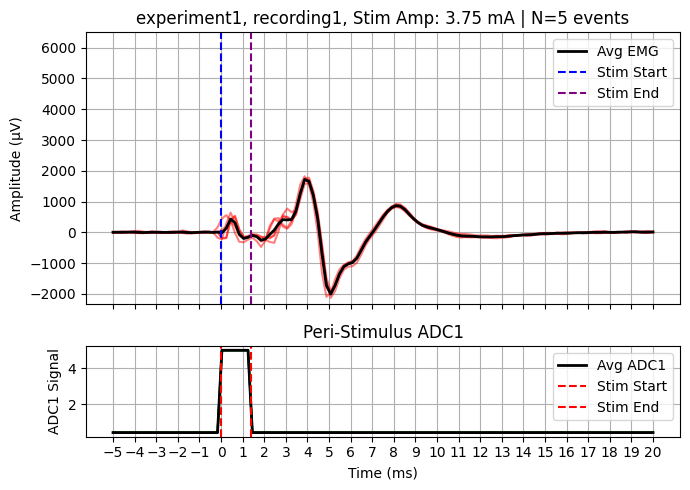

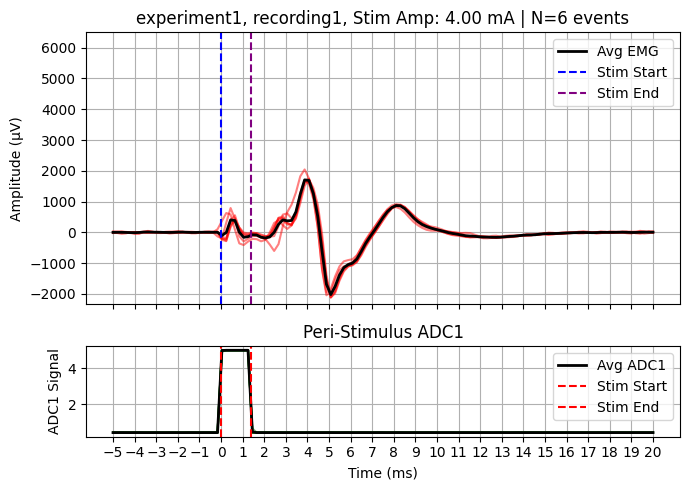

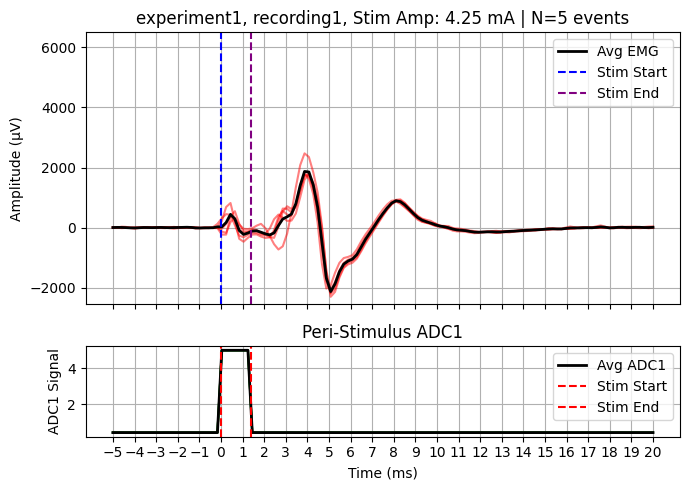

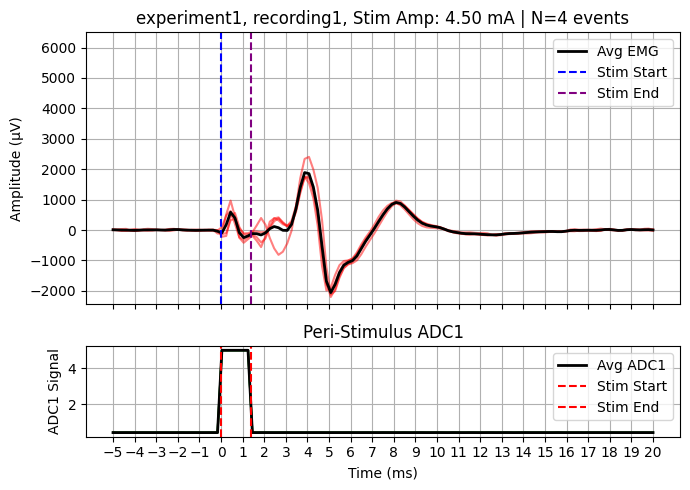

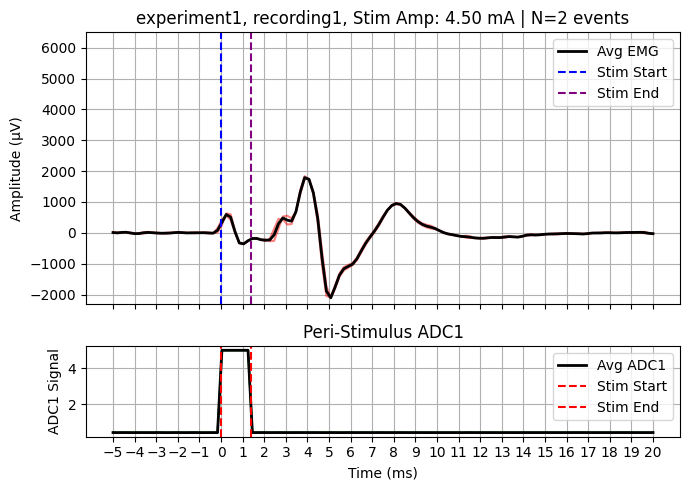

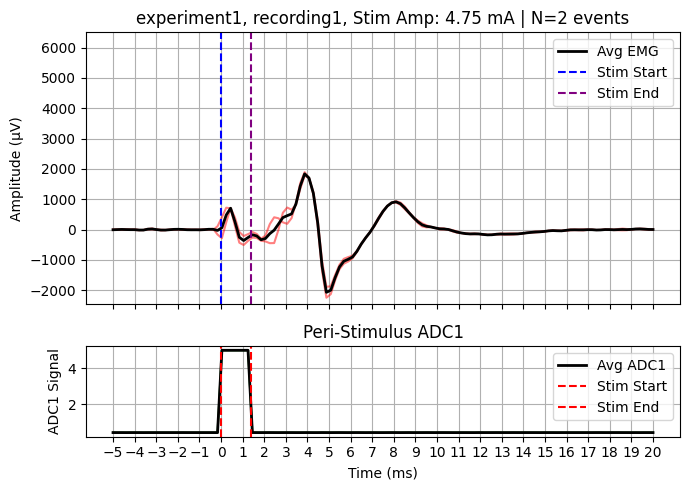

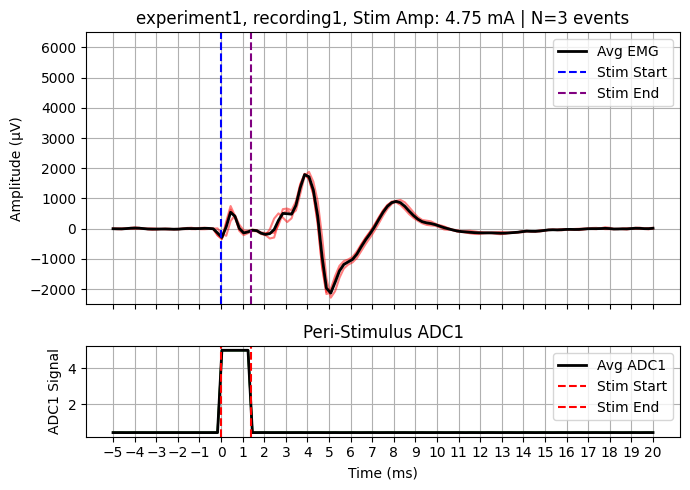

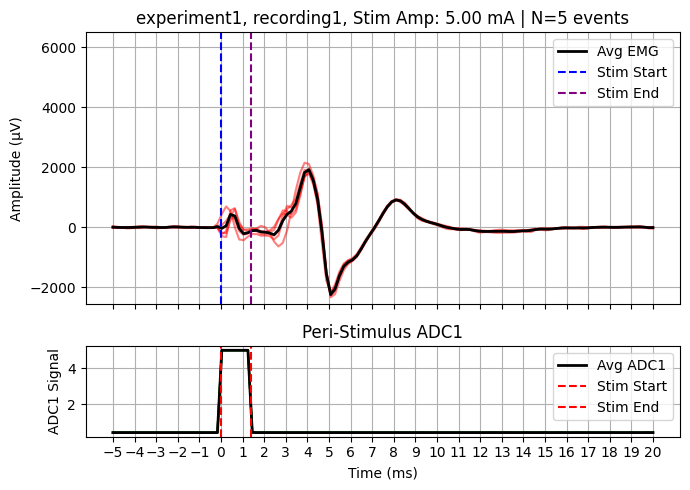

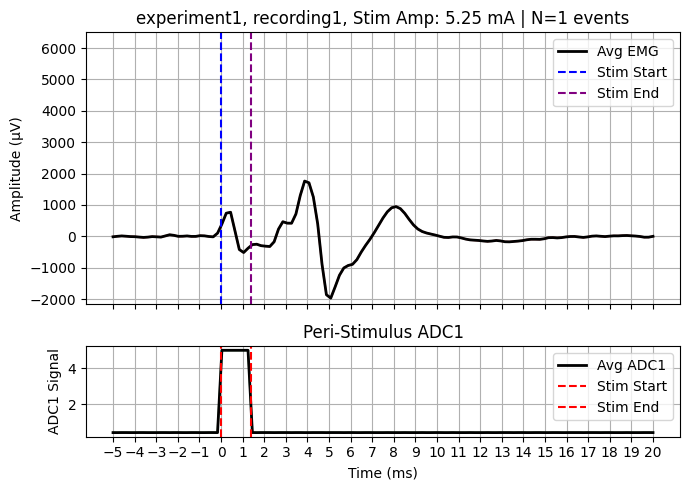

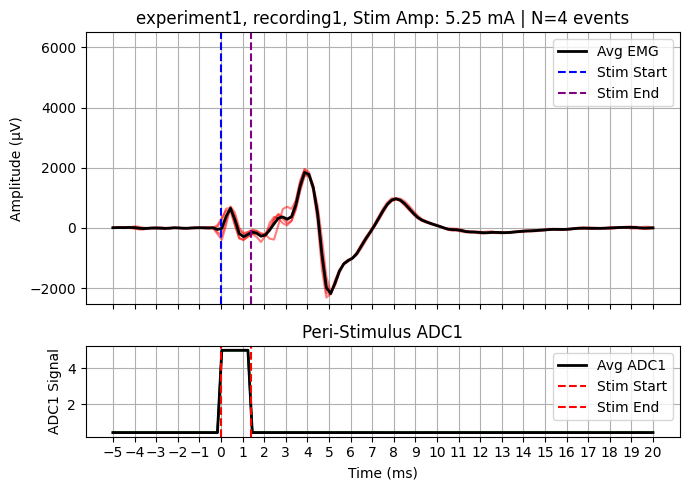

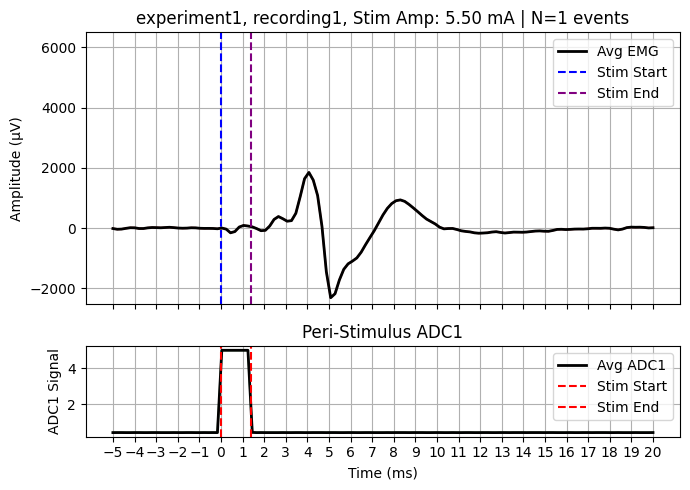

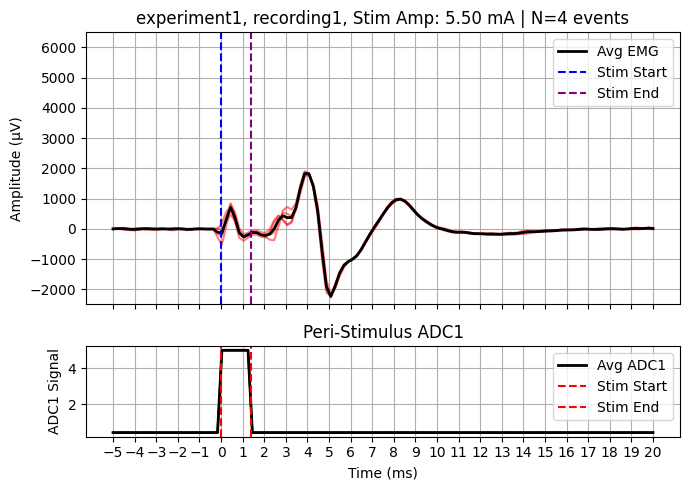

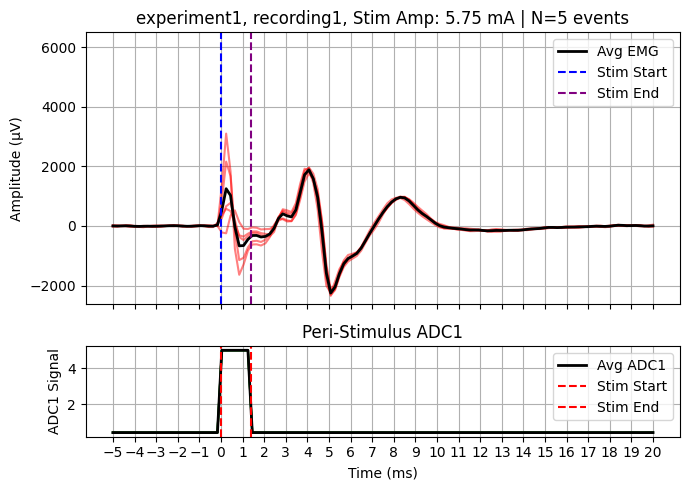

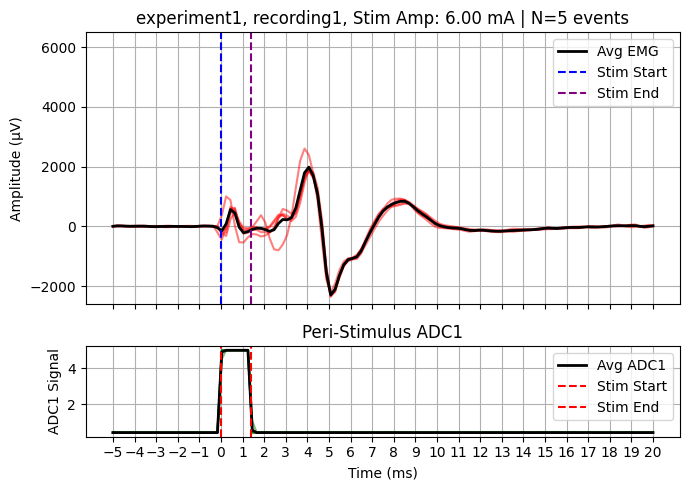

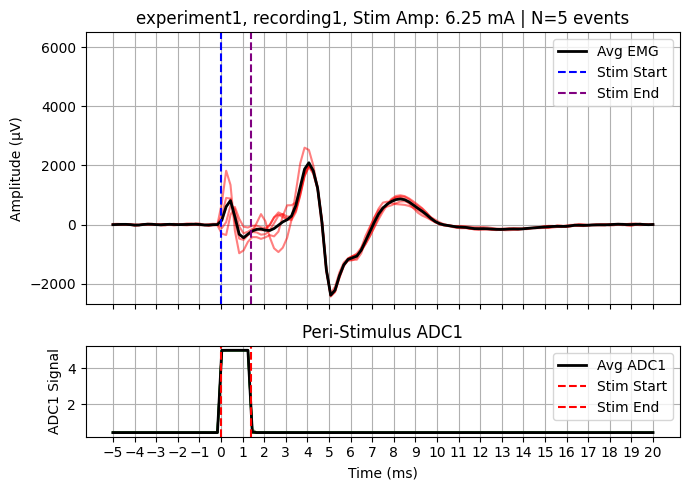

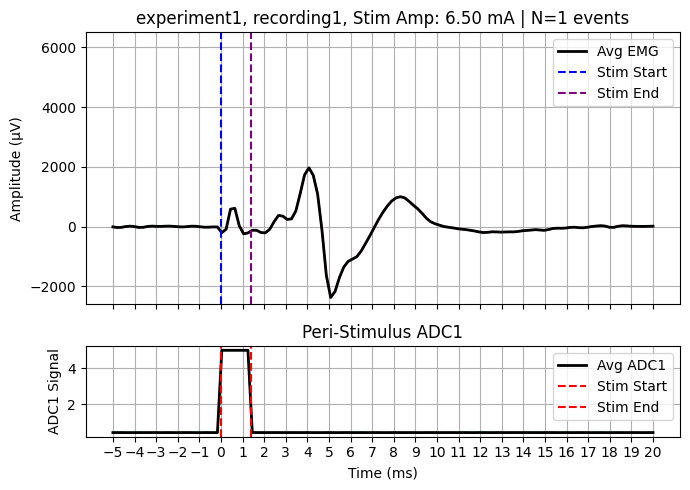

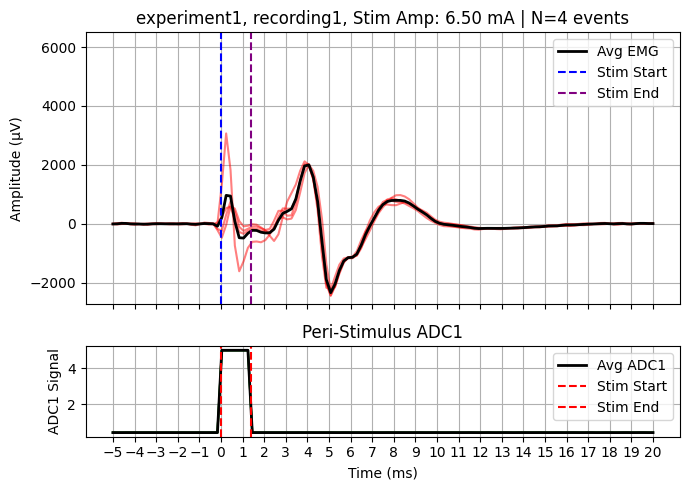

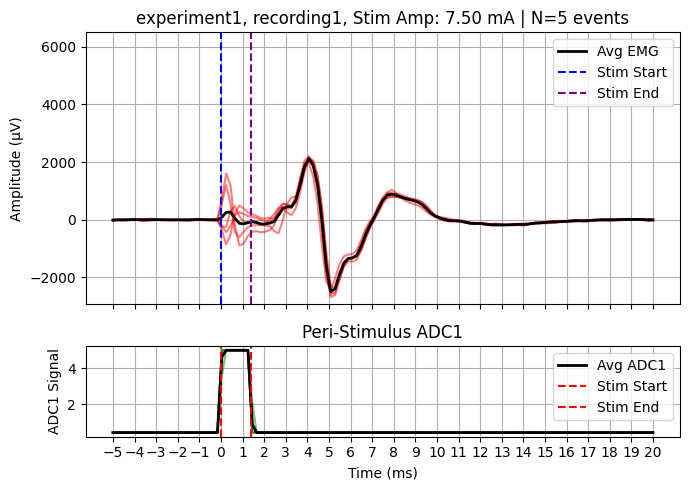

In [9]:

#stim_amp, trigger_times_group = stim_groups[0]
for stim_amp, trigger_times_group in stim_groups:
    group_emg = []
    group_adc1 = []
    group_end_times = []
    group_start_times = []

    for trig_time in trigger_times_group:
        idx_match = np.argmin(np.abs(np.array(segment_stim_start_times) - trig_time))
        if abs(segment_stim_start_times[idx_match] - trig_time) < 0.1:
            group_emg.append(peri_stim_segments_emg[idx_match])
            group_adc1.append(peri_stim_segments_adc1[idx_match])
            group_end_times.append(segment_stim_end_times[idx_match])
            group_start_times.append(segment_stim_start_times[idx_match])

    if not group_emg:
        continue

    avg_emg  = np.mean(group_emg, axis=0)
    avg_adc1 = np.mean(group_adc1, axis=0)
    #avg_end_time = np.mean(group_end_times)
    avg_end_time = np.mean(segment_stim_end_times)  # ms after stim start

    fig, axs = plt.subplots(2, 1, figsize=(7, 5), sharex=True, gridspec_kw={'height_ratios':[3,1]})

    for trace in group_emg:
        axs[0].plot(time_ms, trace, color='red', alpha=0.5)
    axs[0].plot(time_ms, avg_emg, color='black', linewidth=2, label='Avg EMG')
    axs[0].axvline(0, color='blue', linestyle='--', label='Stim Start')
    axs[0].axvline(stim_end_time, color='purple', linestyle='--', label='Stim End')
    axs[0].set_title(f"{exp}, {y}, Stim Amp: {stim_amp:.2f} mA | N={len(group_emg)} events")
    axs[0].set_ylabel("Amplitude (μV)")
    axs[0].legend()
    axs[0].grid(True)
    axs[0].set_ylim(top=6500)

    for trace in group_adc1:
        axs[1].plot(time_ms, trace, color='green', alpha=0.5)
    axs[1].plot(time_ms, avg_adc1, color='black', linewidth=2, label='Avg ADC1')
    axs[1].axvline(0, color='red', linestyle='--', label='Stim Start')
    axs[1].axvline(stim_end_time, color='red', linestyle='--', label='Stim End')
    axs[1].set_title("Peri-Stimulus ADC1")
    axs[1].set_xlabel("Time (ms)")
    axs[1].set_ylabel("ADC1 Signal")
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_xticks(np.arange(int(time_ms[0]), int(time_ms[-1])+1, 1))

    plt.tight_layout()
    plt.show()
    